## Hand Code

In [1]:
#import library yang dibutuhkan
import pandas as pd

In [2]:
df=pd.read_csv("Masterdataset.csv")
df.head()

,id_nasabah,nama,jenis_kelamin,usia,status_pernikaha,jumlah_tanggunga,pendapatan_per_b,lama_bekerja_tah,jenis_pekerjaan,pendidikan,...,jenis_kredit,tenor_bulan,bunga_per_tahun,cicilan_per_bula,rasio_utang_pend,tanggal_akun_dib,is_default,jumlah_tunggakan,riwayat_tunggaka,skor_kredit_sebe
0,NBS-00001,Wahyu Setiawan,P,26,Belum Menikah,2.0,6193292.0,1.0,Karyawan Swasta,S1,...,KKB,49,6.83,2577223,0.416,2025-05-10,0,4,Pernah 3x atau lebih,593.0
1,NBS-00002,Joko Tanjung,P,31,Cerai,2.0,20491471.0,1.0,Pengusaha,SMA,...,Multiguna,71,8.10,1208811,0.059,2019-01-25,0,0,Tidak Pernah,727.0
2,NBS-00003,Nanda Santoso,P,47,Belum Menikah,2.0,4805010.0,14.0,PNS,SMA,...,Kartu Kredit,15,19.87,964941,0.201,2023-06-30,0,3,Pernah 3x atau lebih,652.0
3,NBS-00004,Sari Valentino,P,47,Menikah,1.0,5389523.0,24.0,Karyawan Swasta,S1,...,KPR,193,17.97,5941643,NaN,2022-07-26,0,1,Pernah 1x,693.0
4,NBS-00005,Joko Kusuma,L,38,Menikah,3.0,4467399.0,11.0,Karyawan Swasta,SMA,...,KPR,217,11.02,4864103,1.089,2021-05-11,0,0,Tidak Pernah,733.0


In [8]:
#melihat shape dataset
df.shape    

(20525, 24)

In [11]:
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Jumlah baris: 20525
Jumlah kolom: 24


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20525 entries, 0 to 20524
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_nasabah        20525 non-null  str    
 1   nama              20525 non-null  str    
 2   jenis_kelamin     20525 non-null  str    
 3   usia              20525 non-null  int64  
 4   status_pernikaha  20525 non-null  str    
 5   jumlah_tanggunga  20095 non-null  float64
 6   pendapatan_per_b  19454 non-null  float64
 7   lama_bekerja_tah  19896 non-null  float64
 8   jenis_pekerjaan   20525 non-null  str    
 9   pendidikan        20525 non-null  str    
 10  kota              20525 non-null  str    
 11  jumlah_kredit_ak  20525 non-null  int64  
 12  total_kredit      19541 non-null  float64
 13  sisa_bayar_kredi  18515 non-null  float64
 14  jenis_kredit      20525 non-null  str    
 15  tenor_bulan       20525 non-null  int64  
 16  bunga_per_tahun   20525 non-null  float64
 17  cici

In [25]:
#Diagnosa Missing Value
missing_values = df.isnull().sum()
# print(missing_values)
missing_value=missing_values[missing_values > 0]

In [15]:
column_names = ["id_nasabah", "nama_nasabah", "jenis_kelamin", "usia", "pekerjaan", "pendapatan_bulanan", "jumlah_tanggungan", "status_pernikahan", "status_rumah", "jumlah_kendaraan", "riwayat_kredit_buruk", "jumlah_transaksi_6bulan_terakhir", "rata_rata_transaksi_6bulan_terakhir", "label"
                ]
print(column_names)

['id_nasabah', 'nama_nasabah', 'jenis_kelamin', 'usia', 'pekerjaan', 'pendapatan_bulanan', 'jumlah_tanggungan', 'status_pernikahan', 'status_rumah', 'jumlah_kendaraan', 'riwayat_kredit_buruk', 'jumlah_transaksi_6bulan_terakhir', 'rata_rata_transaksi_6bulan_terakhir', 'label']


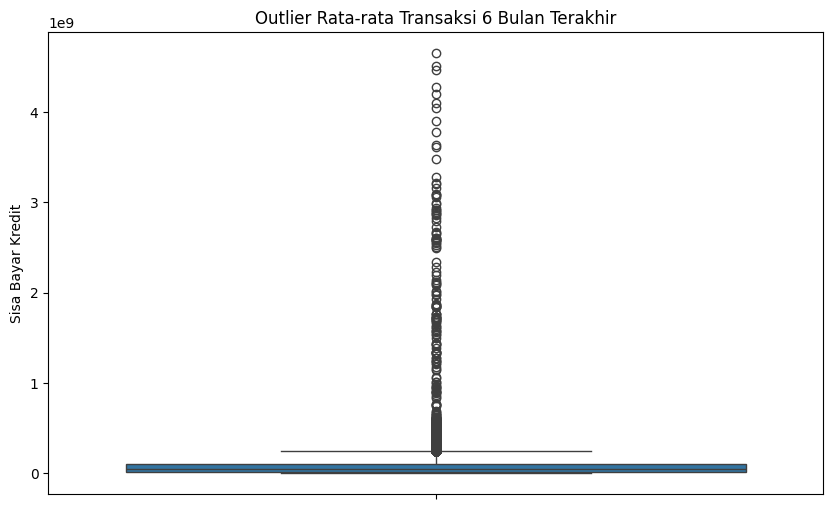

In [23]:
#melihat outlier kolom sisa_bayar_kredi
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['sisa_bayar_kredi'])
plt.title('Outlier Rata-rata Transaksi 6 Bulan Terakhir')
plt.ylabel('Sisa Bayar Kredit')
plt.show()

In [28]:
#menghitung persen missing value dalam bentuk dataframe baru dan sort by persentase missing value
missing_value_percent = (missing_value / len(df)) * 100
missing_value_percent_df = pd.DataFrame({'Kolom': missing_value.index, 'Persentase Missing Value': missing_value_percent.values})
missing_value_percent_df = missing_value_percent_df.sort_values(by='Persentase Missing Value', ascending=False)
print(missing_value_percent_df)

              Kolom  Persentase Missing Value
4  sisa_bayar_kredi                  9.792935
7  skor_kredit_sebe                  8.185140
1  pendapatan_per_b                  5.218027
5  rasio_utang_pend                  5.023143
3      total_kredit                  4.794153
6  riwayat_tunggaka                  3.069428
2  lama_bekerja_tah                  3.064555
0  jumlah_tanggunga                  2.095006


<Axes: >

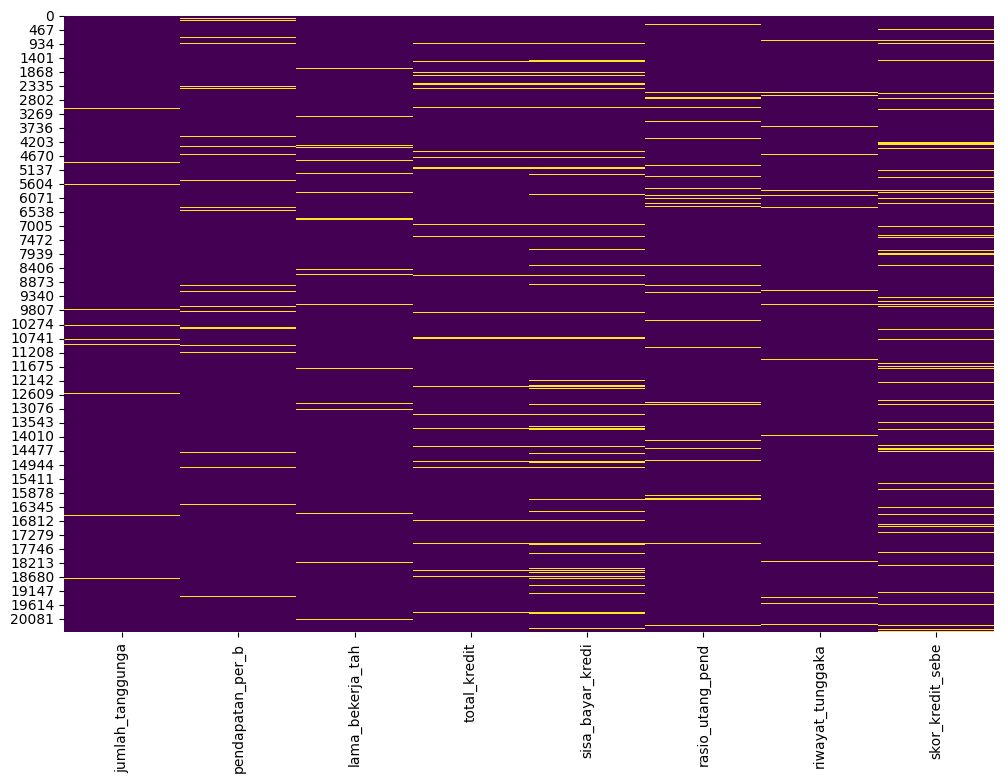

In [30]:
#melakukan visualisasi dengan heatmap menggunakan untuk kolom yang punya missing value
plt.figure(figsize=(12, 8))
sns.heatmap(df[missing_value.index].isnull(), cbar=False, cmap='viridis')

In [34]:
#Mengisi kolom missing value menggunakan mean/median/mode
df_isi = df.copy()
kolom_angka = ["sisa_bayar_kredi", "skor_kredit_sebe"]
for kolom in kolom_angka:
    median_val = df_isi[kolom].median()
    df_isi[kolom].fillna(median_val, inplace=True)

C:\Users\andik\AppData\Local\Temp\ipykernel_21424\2594353863.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_isi[kolom].fillna(median_val, inplace=True)
C:\Users\andik\AppData\Local\Temp\ipykernel_21424\2594353863.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

In [37]:
#melihat missing value setelah diisi
missing_values_setelah_isi = df_isi.isnull().sum()
missing_value_setelah_isi = missing_values_setelah_isi[missing_values_setelah_isi > 0]
print(missing_value_setelah_isi)

jumlah_tanggunga     430
pendapatan_per_b    1071
lama_bekerja_tah     629
total_kredit         984
sisa_bayar_kredi    2010
rasio_utang_pend    1031
riwayat_tunggaka     630
skor_kredit_sebe    1680
dtype: int64


In [41]:
kolom_teks = ["riwayat_tunggakan"]

for kolom in kolom_teks:
    if kolom in df_isi.columns and df_isi[kolom].notna().any():
        mode_val = df_isi[kolom].mode(dropna=True).iloc[0]
        df_isi[kolom] = df_isi[kolom].fillna(mode_val)

In [45]:
#describe
df_isi[missing_cols].describe()

,jumlah_tanggunga,pendapatan_per_b,lama_bekerja_tah,total_kredit,sisa_bayar_kredi,rasio_utang_pend,skor_kredit_sebe
count,20095.000000,1.945400e+04,19896.000000,1.954100e+04,1.851500e+04,19494.000000,18845.000000
mean,2.056233,1.179537e+07,9.828357,2.011389e+08,9.961794e+07,0.679710,663.062775
std,1.565314,6.721248e+07,6.866467,3.682538e+08,2.132786e+08,0.598795,81.336195
min,0.000000,1.500000e+06,0.000000,5.000000e+06,2.645940e+05,0.010000,300.000000
25%,1.000000,4.389274e+06,5.000000,4.619815e+07,1.771224e+07,0.262000,625.000000
50%,2.000000,6.138722e+06,9.000000,9.055341e+07,4.095315e+07,0.477000,677.000000
75%,3.000000,8.209945e+06,14.000000,3.009251e+08,1.067358e+08,0.885000,718.000000
max,7.000000,1.195068e+09,40.000000,4.992338e+09,4.653899e+09,2.500000,850.000000


In [47]:
num_missing_cols = [
    "jumlah_tanggunga",
    "pendapatan_per_b",
    "lama_bekerja_tah",
    "total_kredit",
    "sisa_bayar_kredi",
    "rasio_utang_pend",
    "skor_kredit_sebe"
]

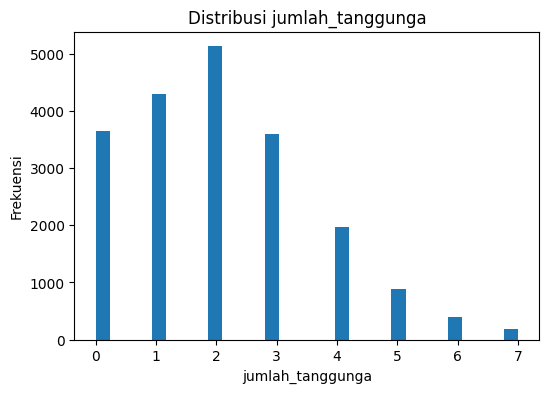

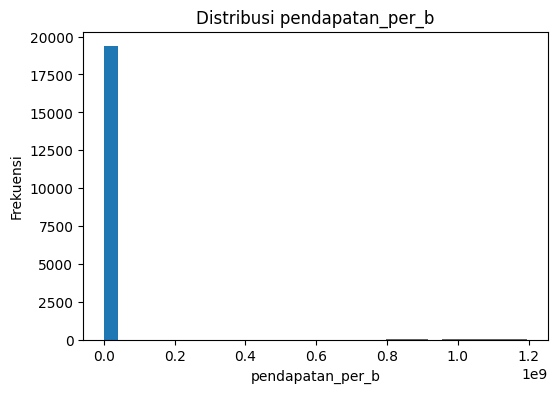

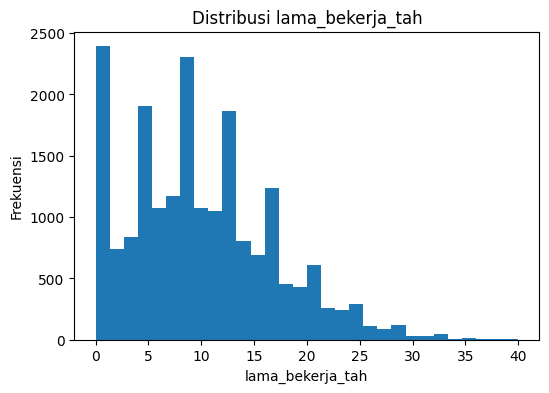

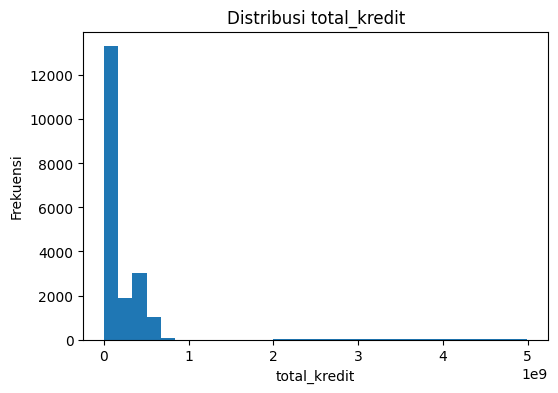

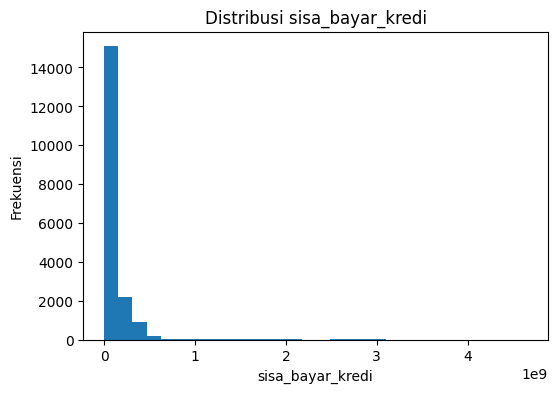

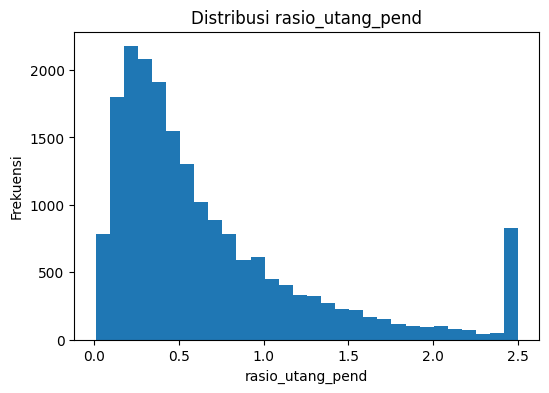

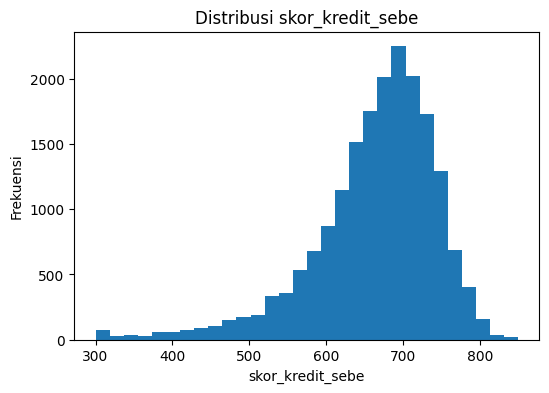

In [48]:
import matplotlib.pyplot as plt

for col in num_missing_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.show()

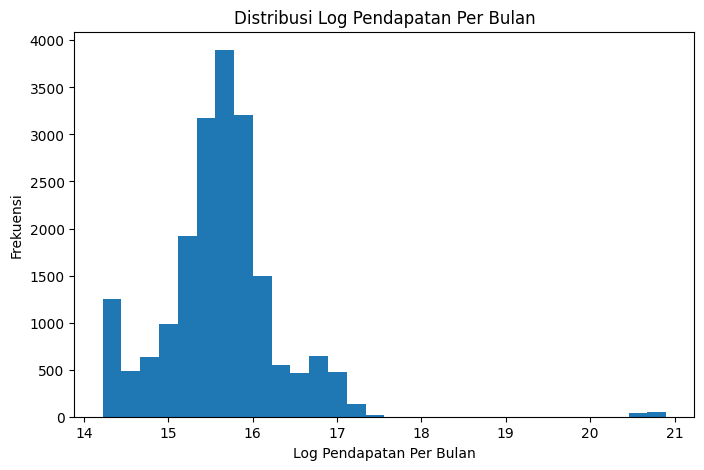

In [56]:
import numpy as np
import matplotlib.pyplot as plt

df["log_pendapatan_per_b"] = np.log1p(df["pendapatan_per_b"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_pendapatan_per_b"].dropna(), bins=30)
plt.title("Distribusi Log Pendapatan Per Bulan")
plt.xlabel("Log Pendapatan Per Bulan")
plt.ylabel("Frekuensi")
plt.show()

| Log Pendapatan | Kira-kira Pendapatan Asli |
| -------------: | ------------------------: |
|             14 |             ± Rp1.200.000 |
|             15 |             ± Rp3.200.000 |
|             16 |             ± Rp8.800.000 |
|             17 |            ± Rp24.000.000 |
|             18 |            ± Rp65.000.000 |
|             20 |           ± Rp485.000.000 |
|             21 |         ± Rp1.300.000.000 |


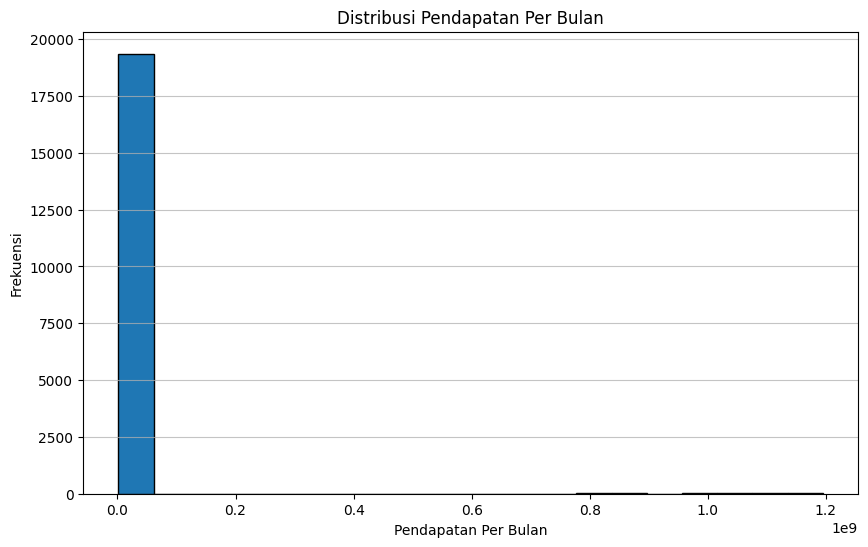

In [54]:
# melihat histogram pendapatan_per_b
plt.figure(figsize=(10, 6))
plt.hist(df['pendapatan_per_b'], bins=20, edgecolor='k')    
plt.title('Distribusi Pendapatan Per Bulan')
plt.xlabel('Pendapatan Per Bulan')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.75)
plt.show()

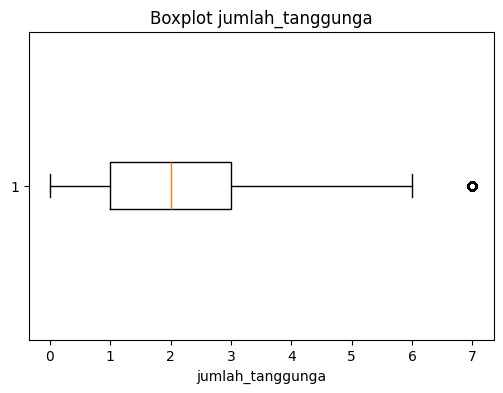

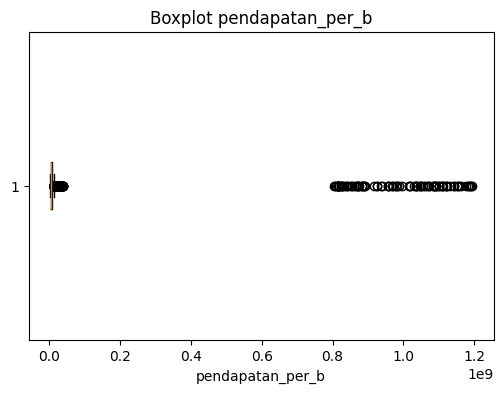

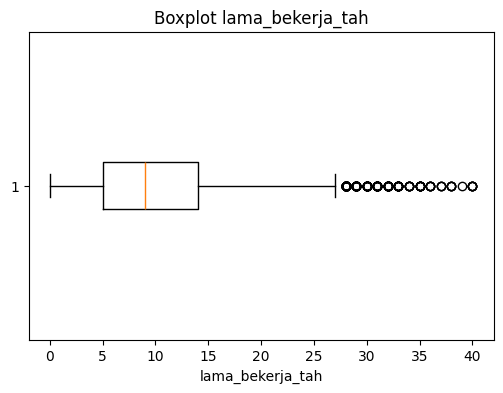

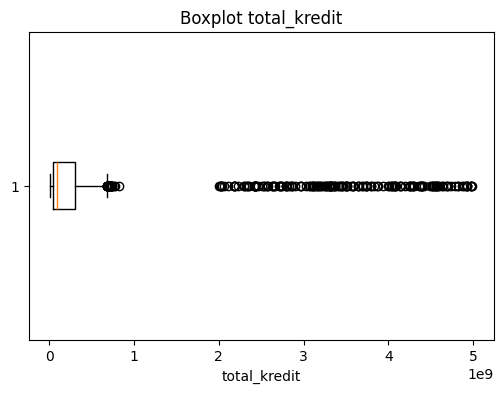

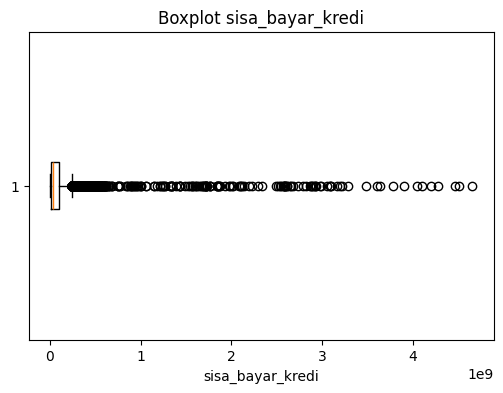

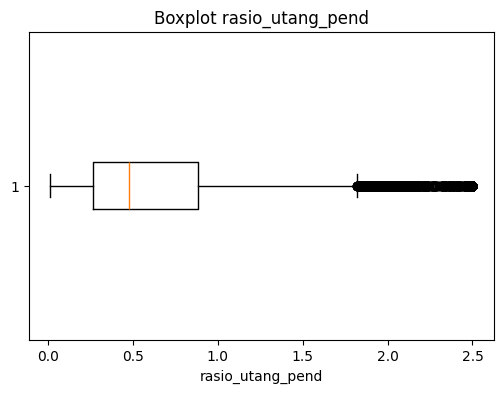

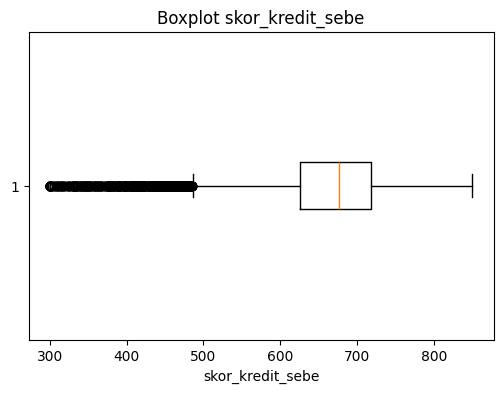

In [49]:
for col in num_missing_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot {col}")
    plt.xlabel(col)
    plt.show()

In [50]:
df[num_missing_cols].skew()

jumlah_tanggunga     0.652282
pendapatan_per_b    14.746557
lama_bekerja_tah     0.640786
total_kredit         7.907746
sisa_bayar_kredi    10.051319
rasio_utang_pend     1.583392
skor_kredit_sebe    -1.282656
dtype: float64

In [51]:
target = "is_default"

for col in missing_cols:
    if target in df.columns:
        print(f"\nDefault rate berdasarkan missing {col}")
        print(df.groupby(df[col].isna())[target].mean())


Default rate berdasarkan missing jumlah_tanggunga
jumlah_tanggunga
False    0.198209
True     0.234884
Name: is_default, dtype: float64

Default rate berdasarkan missing pendapatan_per_b
pendapatan_per_b
False    0.196258
True     0.248366
Name: is_default, dtype: float64

Default rate berdasarkan missing lama_bekerja_tah
lama_bekerja_tah
False    0.200040
True     0.165342
Name: is_default, dtype: float64

Default rate berdasarkan missing total_kredit
total_kredit
False    0.198557
True     0.207317
Name: is_default, dtype: float64

Default rate berdasarkan missing sisa_bayar_kredi
sisa_bayar_kredi
False    0.198488
True     0.203483
Name: is_default, dtype: float64

Default rate berdasarkan missing rasio_utang_pend
rasio_utang_pend
False    0.199856
True     0.182347
Name: is_default, dtype: float64

Default rate berdasarkan missing skor_kredit_sebe
skor_kredit_sebe
False    0.198726
True     0.201786
Name: is_default, dtype: float64


Dari boxplot, mayoritas data pendapatan menumpuk di kiri, sedangkan ada banyak titik jauh di kanan sampai sekitar:1,2 milyar
mean   = Rp11.795.370
median = Rp6.138.722
pendapatan_per_b tidak missing: 19.63%
pendapatan_per_b missing:       24.84%

In [59]:
df.groupby(["jenis_pekerjaan", "pendidikan"])["pendapatan_per_b"].agg(
    count="count",
    median="median"
).sort_values("median", ascending=False)

count      median
jenis_pekerjaan pendidikan                   
Pengusaha       Diploma       366  18130895.5
                SMA           603  18003091.0
                S1           1041  17957258.0
                S2            328  17532692.5
                S3             54  17453673.5
Wiraswasta      S3             69   7019109.0
                SMA          1222   7010102.5
                S1           1793   7007412.0
                Diploma       630   7002596.0
                S2            587   6976025.0
PNS             SMA           912   6053717.0
                S2            463   6050713.0
                Diploma       505   5990029.0
                S1           1502   5942799.0
                S3             88   5795516.5
Karyawan Swasta S2           1088   5596732.0
                S3            155   5570375.0
                SMA          2220   5538987.0
                S1           3517   5476299.0
                Diploma      1202   5396462.5
Tidak Bekerja   S1            454   1519601.0
                S2            127   1512414.0
                SMA           340   1510672.5
                Diploma       165   1500000.0
                S3             23   1500000.0

In [64]:
df[[
    "pendapatan_per_b",
    "total_kredit",
    "sisa_bayar_kredi",
    "cicilan_per_bula",
    "rasio_utang_pend",
    "skor_kredit_sebe",
    "is_default"
]].corr(numeric_only=True)

,pendapatan_per_b,total_kredit,sisa_bayar_kredi,cicilan_per_bula,rasio_utang_pend,skor_kredit_sebe,is_default
pendapatan_per_b,1.000000,0.010716,0.011958,0.005895,-0.109307,-0.010814,-0.056902
total_kredit,0.010716,1.000000,0.845084,0.699996,0.486712,0.011636,0.002596
sisa_bayar_kredi,0.011958,0.845084,1.000000,0.614753,0.415991,0.003317,0.005557
cicilan_per_bula,0.005895,0.699996,0.614753,1.000000,0.290407,0.013878,0.005823
rasio_utang_pend,-0.109307,0.486712,0.415991,0.290407,1.000000,0.000639,0.294684
skor_kredit_sebe,-0.010814,0.011636,0.003317,0.013878,0.000639,1.000000,-0.173827
is_default,-0.056902,0.002596,0.005557,0.005823,0.294684,-0.173827,1.000000


    jenis_pekerjaan pendidikan  count          mean      median           q1  \
2   Karyawan Swasta         S2   1088  1.293534e+07   5596732.0   4262330.50   
3   Karyawan Swasta         S3    155  5.438140e+06   5570375.0   4218597.00   
4   Karyawan Swasta        SMA   2220  9.713608e+06   5538987.0   4201612.25   
1   Karyawan Swasta         S1   3517  9.972624e+06   5476299.0   4138789.00   
0   Karyawan Swasta    Diploma   1202  8.774767e+06   5396462.5   4211402.75   
9               PNS        SMA    912  1.094037e+07   6053717.0   4584936.75   
7               PNS         S2    463  6.112941e+06   6050713.0   4528121.00   
5               PNS    Diploma    505  6.054922e+06   5990029.0   4523193.00   
6               PNS         S1   1502  1.075753e+07   5942799.0   4643048.00   
8               PNS         S3     88  5.738537e+06   5795516.5   4138852.50   
10        Pengusaha    Diploma    366  1.813494e+07  18130895.5  13488305.75   
14        Pengusaha        SMA    603  2

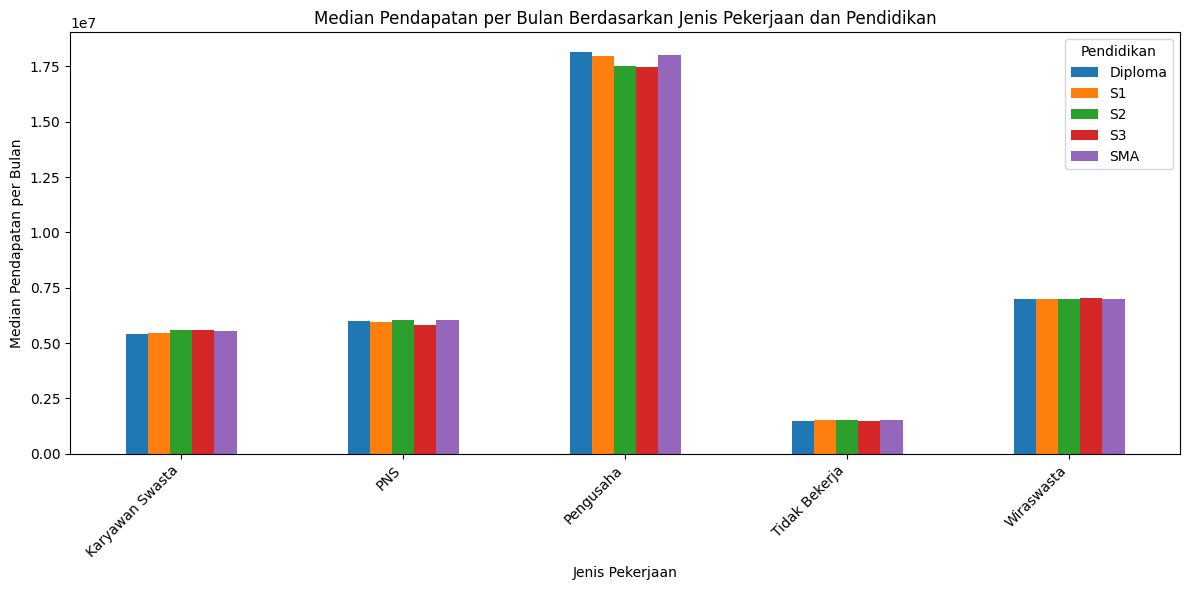

In [73]:
import numpy as np
import matplotlib.pyplot as plt

df["log_pendapatan_per_b"] = np.log1p(df["pendapatan_per_b"])
summary_pendapatan = df.groupby(
    ["jenis_pekerjaan", "pendidikan"]
)["pendapatan_per_b"].agg(
    count="count",
    mean="mean",
    median="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    min="min",
    max="max"
).reset_index()

summary_pendapatan = summary_pendapatan.sort_values(
    ["jenis_pekerjaan", "median"],
    ascending=[True, False]
)

print(summary_pendapatan)
pivot_median = df.pivot_table(
    values="pendapatan_per_b",
    index="jenis_pekerjaan",
    columns="pendidikan",
    aggfunc="median"
)

pivot_median.plot(kind="bar", figsize=(12, 6))

plt.title("Median Pendapatan per Bulan Berdasarkan Jenis Pekerjaan dan Pendidikan")
plt.xlabel("Jenis Pekerjaan")
plt.ylabel("Median Pendapatan per Bulan")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Pendidikan")
plt.tight_layout()
plt.show()

C:\Users\andik\AppData\Local\Temp\ipykernel_21424\4267805791.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_plot, labels=pekerjaan_list, vert=True)


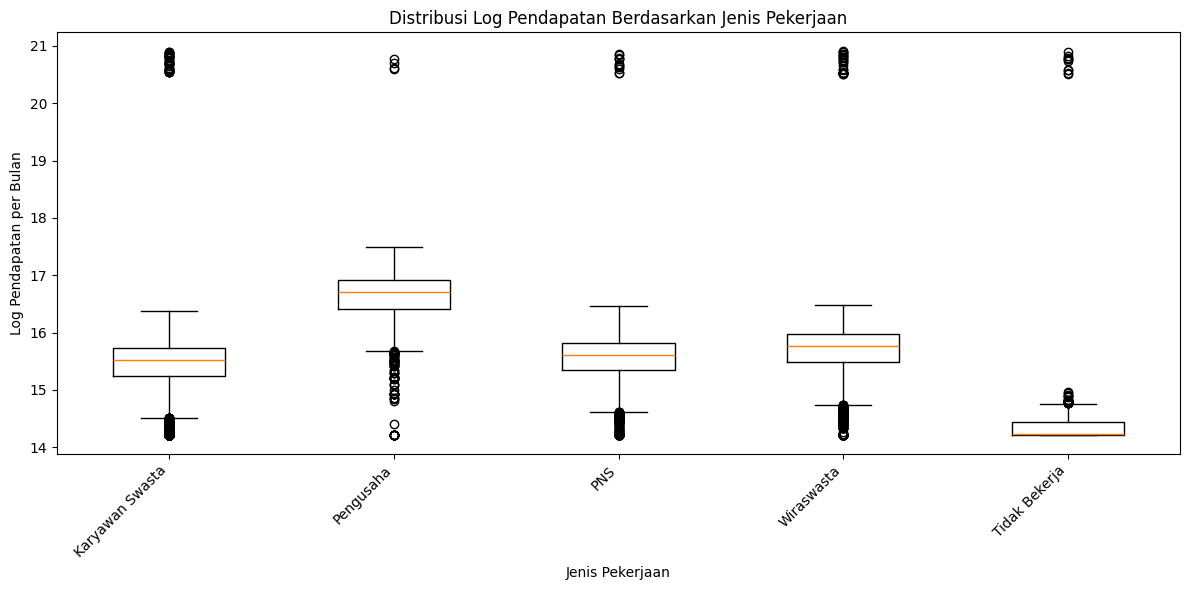

In [74]:
pekerjaan_list = df["jenis_pekerjaan"].dropna().unique()

data_plot = [
    df.loc[df["jenis_pekerjaan"] == pekerjaan, "log_pendapatan_per_b"].dropna()
    for pekerjaan in pekerjaan_list
]

plt.figure(figsize=(12, 6))
plt.boxplot(data_plot, labels=pekerjaan_list, vert=True)

plt.title("Distribusi Log Pendapatan Berdasarkan Jenis Pekerjaan")
plt.xlabel("Jenis Pekerjaan")
plt.ylabel("Log Pendapatan per Bulan")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [72]:
missing_group = df.groupby(
    ["jenis_pekerjaan", "pendidikan"]
)["pendapatan_per_b"].apply(
    lambda x: x.isna().mean() * 100
).reset_index(name="missing_percent")

missing_group = missing_group.sort_values("missing_percent", ascending=False)

print(missing_group)

    jenis_pekerjaan pendidikan  missing_percent
8               PNS         S3         9.278351
17    Tidak Bekerja         S2         7.299270
4   Karyawan Swasta        SMA         6.801008
23       Wiraswasta         S3         6.756757
11        Pengusaha         S1         6.469003
12        Pengusaha         S2         6.285714
0   Karyawan Swasta    Diploma         5.946792
14        Pengusaha        SMA         5.928237
21       Wiraswasta         S1         5.829832
16    Tidak Bekerja         S1         5.809129
6               PNS         S1         5.653266
19    Tidak Bekerja        SMA         5.027933
2   Karyawan Swasta         S2         4.978166
20       Wiraswasta    Diploma         4.833837
10        Pengusaha    Diploma         4.687500
5               PNS    Diploma         4.536862
24       Wiraswasta        SMA         4.231975
1   Karyawan Swasta         S1         4.168937
9               PNS        SMA         4.100946
22       Wiraswasta         S2         4

C:\Users\andik\AppData\Local\Temp\ipykernel_21424\3579004046.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_plot, labels=pendidikan_list, vert=True)


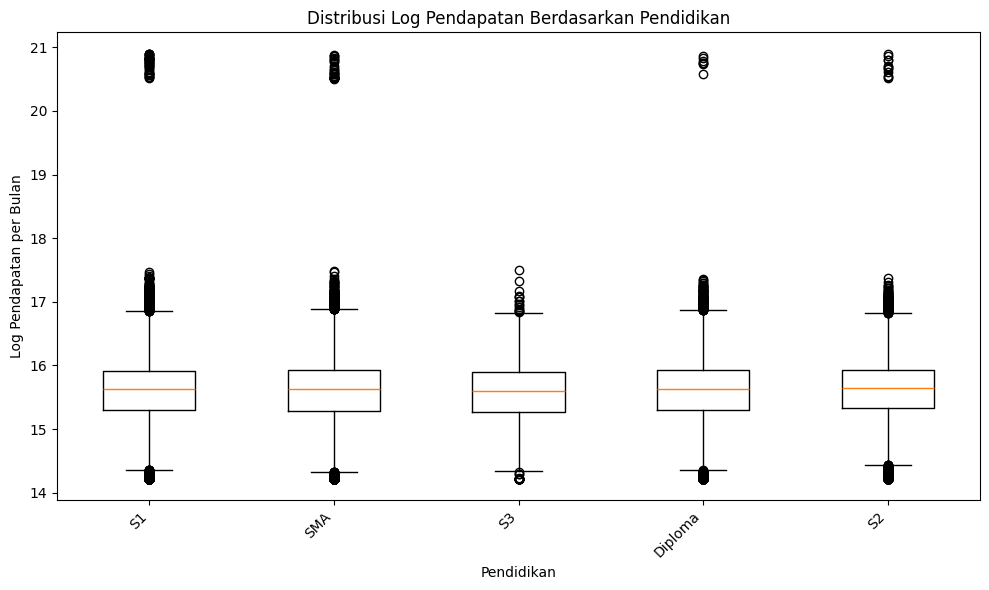

In [75]:
pendidikan_list = df["pendidikan"].dropna().unique()

data_plot = [
    df.loc[df["pendidikan"] == pendidikan, "log_pendapatan_per_b"].dropna()
    for pendidikan in pendidikan_list
]

plt.figure(figsize=(10, 6))
plt.boxplot(data_plot, labels=pendidikan_list, vert=True)

plt.title("Distribusi Log Pendapatan Berdasarkan Pendidikan")
plt.xlabel("Pendidikan")
plt.ylabel("Log Pendapatan per Bulan")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [65]:
df["pendapatan_per_b_missing"] = df["pendapatan_per_b"].isna().astype(int)

df["pendapatan_per_b"] = df.groupby(
    ["jenis_pekerjaan", "pendidikan"]
)["pendapatan_per_b"].transform(lambda x: x.fillna(x.median()))

df["pendapatan_per_b"] = df.groupby(
    "jenis_pekerjaan"
)["pendapatan_per_b"].transform(lambda x: x.fillna(x.median()))

df["pendapatan_per_b"] = df["pendapatan_per_b"].fillna(
    df["pendapatan_per_b"].median()
)

In [66]:
df["pendapatan_per_b"].isna().sum()

np.int64(0)

## Vibe-Code

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20525 entries, 0 to 20524
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_nasabah        20525 non-null  str    
 1   nama              20525 non-null  str    
 2   jenis_kelamin     20525 non-null  str    
 3   usia              20525 non-null  int64  
 4   status_pernikaha  20525 non-null  str    
 5   jumlah_tanggunga  20095 non-null  float64
 6   pendapatan_per_b  19454 non-null  float64
 7   lama_bekerja_tah  19896 non-null  float64
 8   jenis_pekerjaan   20525 non-null  str    
 9   pendidikan        20525 non-null  str    
 10  kota              20525 non-null  str    
 11  jumlah_kredit_ak  20525 non-null  int64  
 12  total_kredit      19541 non-null  float64
 13  sisa_bayar_kredi  18515 non-null  float64
 14  jenis_kredit      20525 non-null  str    
 15  tenor_bulan       20525 non-null  int64  
 16  bunga_per_tahun   20525 non-null  float64
 17  cici

In [4]:
# Melihat missing value masing masing kolom dan persentasenya
missing_values = df.isnull().sum()
missing_value = missing_values[missing_values > 0]
missing_percentage = (missing_value / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_value,
    "missing_percentage": missing_percentage,
})

print(missing_summary)

                  missing_count  missing_percentage
jumlah_tanggunga            430                2.10
pendapatan_per_b           1071                5.22
lama_bekerja_tah            629                3.06
total_kredit                984                4.79
sisa_bayar_kredi           2010                9.79
rasio_utang_pend           1031                5.02
riwayat_tunggaka            630                3.07
skor_kredit_sebe           1680                8.19


### Proses Data Cleaning untuk Mendeteksi dan Mengisi Missing Value

In [5]:
# Mengisi missing value pada kolom sisa bayar kredit dengan median
median_sisa_bayar_kredit = df["sisa_bayar_kredi"].median()
df["sisa_bayar_kredi"] = df["sisa_bayar_kredi"].fillna(median_sisa_bayar_kredit)

print("Median sisa_bayar_kredi:", median_sisa_bayar_kredit)
print("Sisa missing value:", df["sisa_bayar_kredi"].isna().sum())

Median sisa_bayar_kredi: 40953147.0
Sisa missing value: 0


In [6]:
# Mengisi missing value sisa_bayar_kredi dengan rata-rata bertingkat berdasarkan pekerjaan, rasio utang, dan status default
kolom_target = "sisa_bayar_kredi"

# Buat bucket rasio utang pendapatan agar pengelompokan numerik lebih stabil
rasio_bucket = pd.qcut(df["rasio_utang_pend"], q=5, duplicates="drop")

# Imputasi utama: rata-rata per kombinasi pekerjaan, bucket rasio utang, dan is_default
group_mean = df.groupby(["jenis_pekerjaan", rasio_bucket, "is_default"])[kolom_target].transform("mean")
df[kolom_target] = df[kolom_target].fillna(group_mean)

# Fallback bila masih ada missing value
if df[kolom_target].isna().any():
    group_mean_pekerjaan_default = df.groupby(["jenis_pekerjaan", "is_default"])[kolom_target].transform("mean")
    df[kolom_target] = df[kolom_target].fillna(group_mean_pekerjaan_default)

if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].median())

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print("Contoh median keseluruhan:", df[kolom_target].median())
#print skor kredit sebelumnya berdasar pekerjaan, rasio utang, dan status default
group_skor = df.groupby(["jenis_pekerjaan", rasio_bucket, "is_default"])["skor_kredit_sebe"].mean().reset_index()
print(group_skor)


Sisa missing value setelah imputasi: 0
Contoh median keseluruhan: 40953147.0
    jenis_pekerjaan               rasio_utang_pend  is_default  \
0   Karyawan Swasta  (0.009000000000000001, 0.227]           0   
1   Karyawan Swasta  (0.009000000000000001, 0.227]           1   
2   Karyawan Swasta                 (0.227, 0.381]           0   
3   Karyawan Swasta                 (0.227, 0.381]           1   
4   Karyawan Swasta                 (0.381, 0.599]           0   
5   Karyawan Swasta                 (0.381, 0.599]           1   
6   Karyawan Swasta                 (0.599, 1.026]           0   
7   Karyawan Swasta                 (0.599, 1.026]           1   
8   Karyawan Swasta                   (1.026, 2.5]           0   
9   Karyawan Swasta                   (1.026, 2.5]           1   
10              PNS  (0.009000000000000001, 0.227]           0   
11              PNS  (0.009000000000000001, 0.227]           1   
12              PNS                 (0.227, 0.381]           0   

In [7]:
# Mengisi missing value pada pendapatan_per_b berdasarkan jenis pekerjaan dan total kredit
kolom_target = "pendapatan_per_b"

# Rata-rata per kelompok pekerjaan dan total kredit
group_mean = df.groupby(["jenis_pekerjaan", "total_kredit"])[kolom_target].transform("mean")
df[kolom_target] = df[kolom_target].fillna(group_mean)

# Fallback jika masih ada missing value
if df[kolom_target].isna().any():
    job_mean = df.groupby("jenis_pekerjaan")[kolom_target].transform("mean")
    df[kolom_target] = df[kolom_target].fillna(job_mean)

if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].median())

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df.groupby(["jenis_pekerjaan", "total_kredit"])[kolom_target].mean().head())

Sisa missing value setelah imputasi: 0
jenis_pekerjaan  total_kredit
Karyawan Swasta  5000000.0       6.052852e+06
                 5538785.0       7.893009e+06
                 5628375.0       1.500000e+06
                 5818233.0       5.512216e+06
                 6161789.0       9.754422e+06
Name: pendapatan_per_b, dtype: float64


In [8]:
# Mengisi missing value pada rasio_utang_pend dengan perhitungan per nasabah
kolom_target = "rasio_utang_pend"

rasio_hitung = df["cicilan_per_bula"] / df["pendapatan_per_b"]
df[kolom_target] = df[kolom_target].fillna(rasio_hitung)

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["cicilan_per_bula", "pendapatan_per_b", kolom_target]].head())


Sisa missing value setelah imputasi: 0
   cicilan_per_bula  pendapatan_per_b  rasio_utang_pend
0           2577223         6193292.0          0.416000
1           1208811        20491471.0          0.059000
2            964941         4805010.0          0.201000
3           5941643         5389523.0          1.102443
4           4864103         4467399.0          1.089000


In [9]:
# Mengisi missing value pada total_kredit dengan tenor_bulan dikali cicilan_per_bula
kolom_target = "total_kredit"

total_kredit_hitung = df["tenor_bulan"] * df["cicilan_per_bula"]
df[kolom_target] = df[kolom_target].fillna(total_kredit_hitung)

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["tenor_bulan", "cicilan_per_bula", kolom_target]].head())

Sisa missing value setelah imputasi: 0
   tenor_bulan  cicilan_per_bula  total_kredit
0           49           2577223   109932189.0
1           71           1208811    68007609.0
2           15            964941    12724081.0
3          193           5941643   374246142.0
4          217           4864103   456805049.0


In [10]:
# Mengisi missing value pada riwayat_tunggaka berdasarkan jumlah_tunggakan
kolom_target = "riwayat_tunggaka"

# Isi dengan kategori yang paling sering muncul pada setiap jumlah_tunggakan
group_mode = df.groupby("jumlah_tunggakan")[kolom_target].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA
)
df[kolom_target] = df[kolom_target].fillna(group_mode)

# Fallback ke mode global jika masih ada missing value
if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].mode().iloc[0])

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["jumlah_tunggakan", kolom_target]].head())

Sisa missing value setelah imputasi: 0
   jumlah_tunggakan      riwayat_tunggaka
0                 4  Pernah 3x atau lebih
1                 0          Tidak Pernah
2                 3  Pernah 3x atau lebih
3                 1             Pernah 1x
4                 0          Tidak Pernah


In [11]:
# Mengisi missing value pada lama_bekerja_tah berdasarkan rentang usia dan rentang pendapatan di tiap rentang usia
kolom_target = "lama_bekerja_tah"

# Buat rentang usia
usia_bins = [17, 25, 35, 45, 55, 65, 100]
usia_label = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["usia_range"] = pd.cut(df["usia"], bins=usia_bins, labels=usia_label, include_lowest=True)

# Buat rentang pendapatan di dalam setiap rentang usia
pendapatan_range = pd.Series(index=df.index, dtype="object")
for label in usia_label:
    mask = df["usia_range"] == label
    if mask.any():
        try:
            pendapatan_range.loc[mask] = pd.qcut(
                df.loc[mask, "pendapatan_per_b"],
                q=4,
                duplicates="drop"
            ).astype(str)
        except Exception:
            pendapatan_range.loc[mask] = "all"

df["pendapatan_range_usia"] = pendapatan_range

# Median lama bekerja berdasarkan kombinasi rentang usia dan rentang pendapatan
group_median = df.groupby(["usia_range", "pendapatan_range_usia"])[kolom_target].transform("median")
df[kolom_target] = df[kolom_target].fillna(group_median)

# Fallback bertahap bila masih ada missing value
if df[kolom_target].isna().any():
    age_median = df.groupby("usia_range")[kolom_target].transform("median")
    df[kolom_target] = df[kolom_target].fillna(age_median)

if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].median())

# Rapikan kolom bantu jika tidak ingin dipakai lagi
df.drop(columns=["usia_range", "pendapatan_range_usia"], inplace=True)

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["usia", "pendapatan_per_b", kolom_target]].head())

Sisa missing value setelah imputasi: 0
   usia  pendapatan_per_b  lama_bekerja_tah
0    26         6193292.0               1.0
1    31        20491471.0               1.0
2    47         4805010.0              14.0
3    47         5389523.0              24.0
4    38         4467399.0              11.0


In [12]:
# Mengisi missing value pada jumlah_tanggunga berdasarkan rentang usia dan rentang pendapatan di tiap rentang usia
kolom_target = "jumlah_tanggunga"

# Buat rentang usia
usia_bins = [17, 25, 35, 45, 55, 65, 100]
usia_label = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["usia_range"] = pd.cut(df["usia"], bins=usia_bins, labels=usia_label, include_lowest=True)

# Buat rentang pendapatan pada tiap rentang usia
pendapatan_range_usia = pd.Series(index=df.index, dtype="object")
for label_usia in usia_label:
    mask = df["usia_range"] == label_usia
    if mask.any():
        try:
            pendapatan_range_usia.loc[mask] = pd.qcut(
                df.loc[mask, "pendapatan_per_b"],
                q=4,
                duplicates="drop"
            ).astype(str)
        except Exception:
            pendapatan_range_usia.loc[mask] = "all"

df["pendapatan_range_usia"] = pendapatan_range_usia

# Median jumlah tanggungan berdasarkan kombinasi rentang usia dan rentang pendapatan
group_median = df.groupby(["usia_range", "pendapatan_range_usia"])[kolom_target].transform("median")
df[kolom_target] = df[kolom_target].fillna(group_median)

# Fallback bertahap bila masih ada missing value
if df[kolom_target].isna().any():
    age_median = df.groupby("usia_range")[kolom_target].transform("median")
    df[kolom_target] = df[kolom_target].fillna(age_median)

if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].median())

# Hapus kolom bantu
df.drop(columns=["usia_range", "pendapatan_range_usia"], inplace=True)

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["usia", "pendapatan_per_b", kolom_target]].head())

Sisa missing value setelah imputasi: 0
   usia  pendapatan_per_b  jumlah_tanggunga
0    26         6193292.0               2.0
1    31        20491471.0               2.0
2    47         4805010.0               2.0
3    47         5389523.0               1.0
4    38         4467399.0               3.0


In [13]:
# Mengisi missing value pada skor_kredit_sebe dengan mempertimbangkan beberapa variabel
kolom_target = "skor_kredit_sebe"

# Bucket rasio utang dan pendapatan agar grouping lebih stabil
rasio_bucket = pd.qcut(df["rasio_utang_pend"], q=5, duplicates="drop")
pendapatan_bucket = pd.qcut(df["pendapatan_per_b"], q=5, duplicates="drop")

# Imputasi utama: median per kombinasi variabel
group_median = df.groupby(["jenis_pekerjaan", "pendidikan", rasio_bucket, pendapatan_bucket, "is_default"])[kolom_target].transform("median")
df[kolom_target] = df[kolom_target].fillna(group_median)

# Fallback bertahap jika masih ada missing value
if df[kolom_target].isna().any():
    fallback_1 = df.groupby(["jenis_pekerjaan", rasio_bucket, "is_default"])[kolom_target].transform("median")
    df[kolom_target] = df[kolom_target].fillna(fallback_1)

if df[kolom_target].isna().any():
    fallback_2 = df.groupby(["jenis_pekerjaan", "is_default"])[kolom_target].transform("median")
    df[kolom_target] = df[kolom_target].fillna(fallback_2)

if df[kolom_target].isna().any():
    df[kolom_target] = df[kolom_target].fillna(df[kolom_target].median())

print("Sisa missing value setelah imputasi:", df[kolom_target].isna().sum())
print(df[["jenis_pekerjaan", "pendidikan", "rasio_utang_pend", "pendapatan_per_b", "is_default", kolom_target]].head())

Sisa missing value setelah imputasi: 0
   jenis_pekerjaan pendidikan  rasio_utang_pend  pendapatan_per_b  is_default  \
0  Karyawan Swasta         S1          0.416000         6193292.0           0   
1        Pengusaha        SMA          0.059000        20491471.0           0   
2              PNS        SMA          0.201000         4805010.0           0   
3  Karyawan Swasta         S1          1.102443         5389523.0           0   
4  Karyawan Swasta        SMA          1.089000         4467399.0           0   

   skor_kredit_sebe  
0             593.0  
1             727.0  
2             652.0  
3             693.0  
4             733.0  


### Memeriksa dataframe sekarang

In [14]:
# cek missing value setelah semua imputasi
missing_values_final = df.isnull().sum()
missing_value_final = missing_values_final[missing_values_final > 0]
#cek data duplikat dan tampilkan contohnya
duplicate_count = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")
if duplicate_count > 0:
    print("Contoh data duplikat:")
    print(df[df.duplicated(keep=False)])    

Jumlah data duplikat: 525
Contoh data duplikat:
      id_nasabah             nama jenis_kelamin  usia status_pernikaha  \
9      NBS-00010   Putri Maharani             P    25            Cerai   
10     NBS-00010   Putri Maharani             P    25            Cerai   
11     NBS-00010   Putri Maharani             P    25            Cerai   
12     NBS-00010   Putri Maharani             P    25            Cerai   
140    NBS-00138     Yudi Pratama             L    54    Belum Menikah   
...          ...              ...           ...   ...              ...   
20520  NBS-02229  Cahyo Kurniawan             L    39    Belum Menikah   
20521  NBS-18751     Umar Suharto             L    36          Menikah   
20522  NBS-18751     Umar Suharto             L    36          Menikah   
20523  NBS-18751     Umar Suharto             L    36          Menikah   
20524  NBS-18751     Umar Suharto             L    36          Menikah   

       jumlah_tanggunga  pendapatan_per_b  lama_bekerja_tah  je

In [15]:
#hapus data duplikat yg isi semua kolomnya sama
df = df.drop_duplicates()
print(f"Jumlah data setelah menghapus duplikat: {len(df)}")
#perbandingkan jumlah data sebelum dan sesudah menghapus duplikat
print(f"Jumlah data sebelum menghapus duplikat: {len(df) + duplicate_count}")

Jumlah data setelah menghapus duplikat: 20000
Jumlah data sebelum menghapus duplikat: 20525


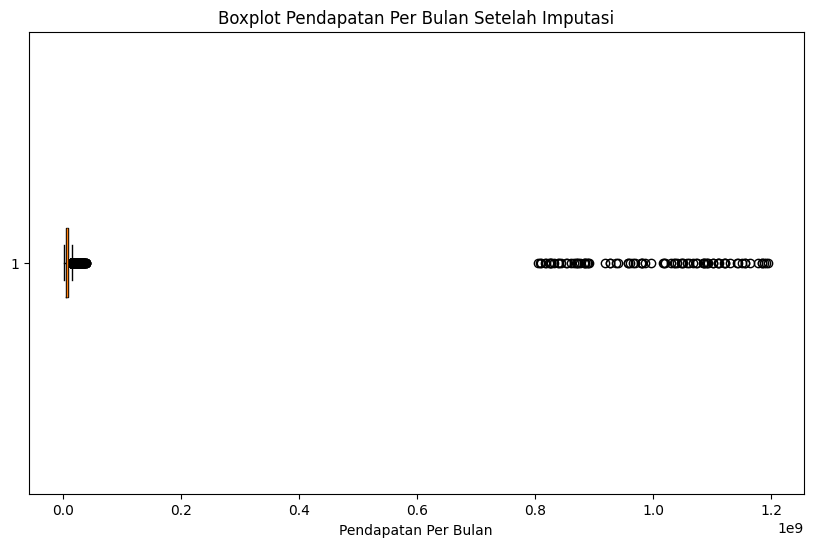

In [17]:
import matplotlib.pyplot as plt
#boxplot kolom pendapatan_per_b setelah imputasi
plt.figure(figsize=(10, 6))
plt.boxplot(df['pendapatan_per_b'], vert=False)
plt.title('Boxplot Pendapatan Per Bulan Setelah Imputasi')
plt.xlabel('Pendapatan Per Bulan')
plt.show()

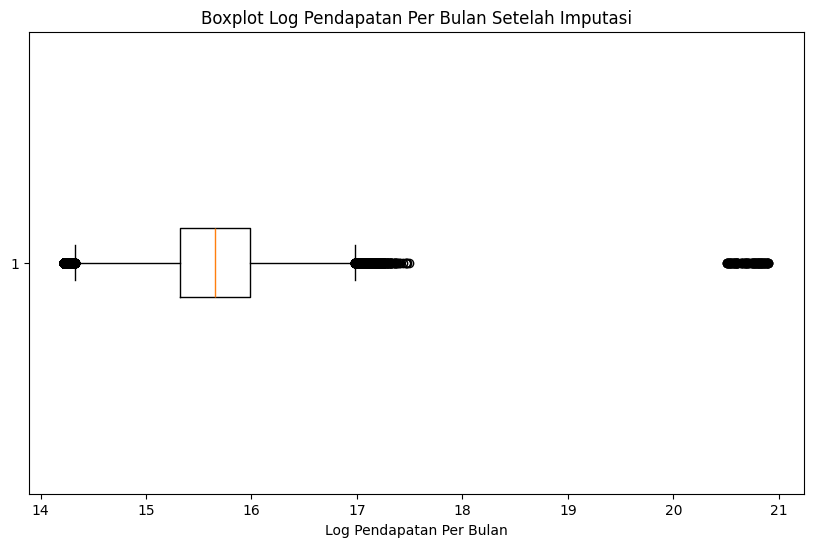

In [18]:
import numpy as np
#buat transformasilog pendapatan per b dan buat boxplotnya
df["log_pendapatan_per_b"] = np.log1p(df["pendapatan_per_b"])
plt.figure(figsize=(10, 6))
plt.boxplot(df['log_pendapatan_per_b'], vert=False)
plt.title('Boxplot Log Pendapatan Per Bulan Setelah Imputasi')
plt.xlabel('Log Pendapatan Per Bulan')
plt.show()

In [19]:
#cek skewneness pendapatan_per_b setelah ditransformasi log
skewness_log = df["log_pendapatan_per_b"].skew()
print(f"Skewness Log Pendapatan Per Bulan: {skewness_log}")

Skewness Log Pendapatan Per Bulan: 1.3843058524568594


In [20]:
batas = df["log_pendapatan_per_b"].quantile(0.99)

df[df["log_pendapatan_per_b"] >= batas][
    [
        "id_nasabah",
        "jenis_pekerjaan",
        "pendidikan",
        "pendapatan_per_b",
        "log_pendapatan_per_b",
        "total_kredit",
        "is_default"
    ]
].sort_values("pendapatan_per_b", ascending=False)

,id_nasabah,jenis_pekerjaan,pendidikan,pendapatan_per_b,log_pendapatan_per_b,total_kredit,is_default
18126,NBS-17938,Wiraswasta,S1,1.195068e+09,20.901469,4.359694e+09,0
13337,NBS-13203,Tidak Bekerja,S1,1.191645e+09,20.898601,1.690462e+08,0
15997,NBS-15839,Wiraswasta,S1,1.187109e+09,20.894786,2.606016e+07,0
875,NBS-00861,Wiraswasta,S1,1.184492e+09,20.892580,3.457302e+07,0
15379,NBS-15221,Karyawan Swasta,S2,1.183638e+09,20.891859,4.510634e+07,0
...,...,...,...,...,...,...,...
19628,NBS-19416,Pengusaha,S1,2.836688e+07,17.160733,4.024931e+08,0
2832,NBS-02791,Pengusaha,S2,2.834851e+07,17.160085,7.897492e+07,0
11075,NBS-10968,Pengusaha,S1,2.829885e+07,17.158332,2.288658e+07,0
20186,NBS-19962,Pengusaha,Diploma,2.827436e+07,17.157466,1.281252e+08,0


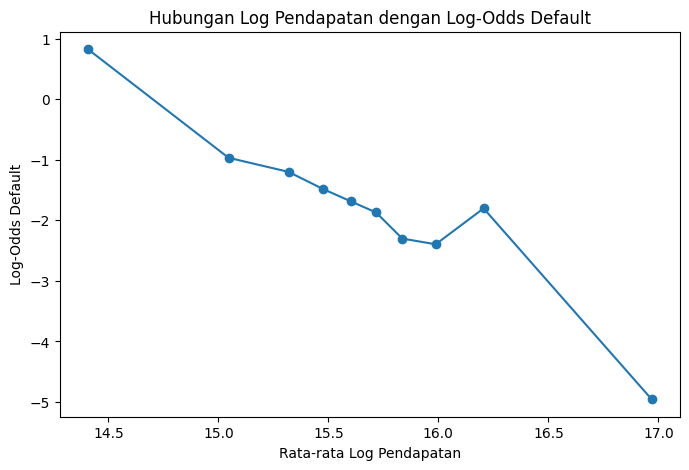

             bucket  rata_log_pendapatan  default_rate  jumlah_data  \
0   (14.22, 14.794]            14.407469        0.6955         2000   
1  (14.794, 15.218]            15.046272        0.2755         2000   
2  (15.218, 15.408]            15.319220        0.2315         2000   
3  (15.408, 15.542]            15.477704        0.1845         2000   
4  (15.542, 15.659]            15.600928        0.1565         2000   
5  (15.659, 15.775]            15.716903        0.1335         2000   
6  (15.775, 15.904]            15.835982        0.0910         2000   
7  (15.904, 16.077]            15.987928        0.0835         2000   
8  (16.077, 16.411]            16.205629        0.1415         2000   
9  (16.411, 20.901]            16.969084        0.0070         2000   

   default_rate_aman  logit_default  
0             0.6955       0.825960  
1             0.2755      -0.966894  
2             0.2315      -1.199861  
3             0.1845      -1.486152  
4             0.1565      -1

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cek_logit = df[
    ["log_pendapatan_per_b", "is_default"]
].dropna().copy()

cek_logit["bucket"] = pd.qcut(
    cek_logit["log_pendapatan_per_b"],
    q=10,
    duplicates="drop"
)

ringkasan = cek_logit.groupby(
    "bucket",
    observed=True
).agg(
    rata_log_pendapatan=("log_pendapatan_per_b", "mean"),
    default_rate=("is_default", "mean"),
    jumlah_data=("is_default", "size")
).reset_index()

epsilon = 1e-6

ringkasan["default_rate_aman"] = ringkasan[
    "default_rate"
].clip(epsilon, 1 - epsilon)

ringkasan["logit_default"] = np.log(
    ringkasan["default_rate_aman"] /
    (1 - ringkasan["default_rate_aman"])
)

plt.figure(figsize=(8, 5))
plt.scatter(
    ringkasan["rata_log_pendapatan"],
    ringkasan["logit_default"]
)
plt.plot(
    ringkasan["rata_log_pendapatan"],
    ringkasan["logit_default"]
)
plt.xlabel("Rata-rata Log Pendapatan")
plt.ylabel("Log-Odds Default")
plt.title("Hubungan Log Pendapatan dengan Log-Odds Default")
plt.show()

print(ringkasan)

In [22]:
p99 = df["pendapatan_per_b"].quantile(0.99)

data_ekstrem = df[
    df["pendapatan_per_b"] > p99
].copy()

ringkasan_ekstrem = data_ekstrem.groupby(
    "jenis_pekerjaan"
).agg(
    jumlah_nasabah=("id_nasabah", "count"),
    pendapatan_min=("pendapatan_per_b", "min"),
    pendapatan_median=("pendapatan_per_b", "median"),
    pendapatan_max=("pendapatan_per_b", "max"),
    default_rate=("is_default", "mean")
).sort_values("jumlah_nasabah", ascending=False)

print(ringkasan_ekstrem)

                 jumlah_nasabah  pendapatan_min  pendapatan_median  \
jenis_pekerjaan                                                      
Pengusaha                   120      28262825.0       3.021871e+07   
Karyawan Swasta              37     831127088.0       1.016024e+09   
Wiraswasta                   21     805019157.0       1.029830e+09   
PNS                          12     826998108.0       9.469419e+08   
Tidak Bekerja                10     809656049.0       1.033890e+09   

                 pendapatan_max  default_rate  
jenis_pekerjaan                                
Pengusaha          1.039619e+09           0.0  
Karyawan Swasta    1.183638e+09           0.0  
Wiraswasta         1.195068e+09           0.0  
PNS                1.142251e+09           0.0  
Tidak Bekerja      1.191645e+09           0.0  


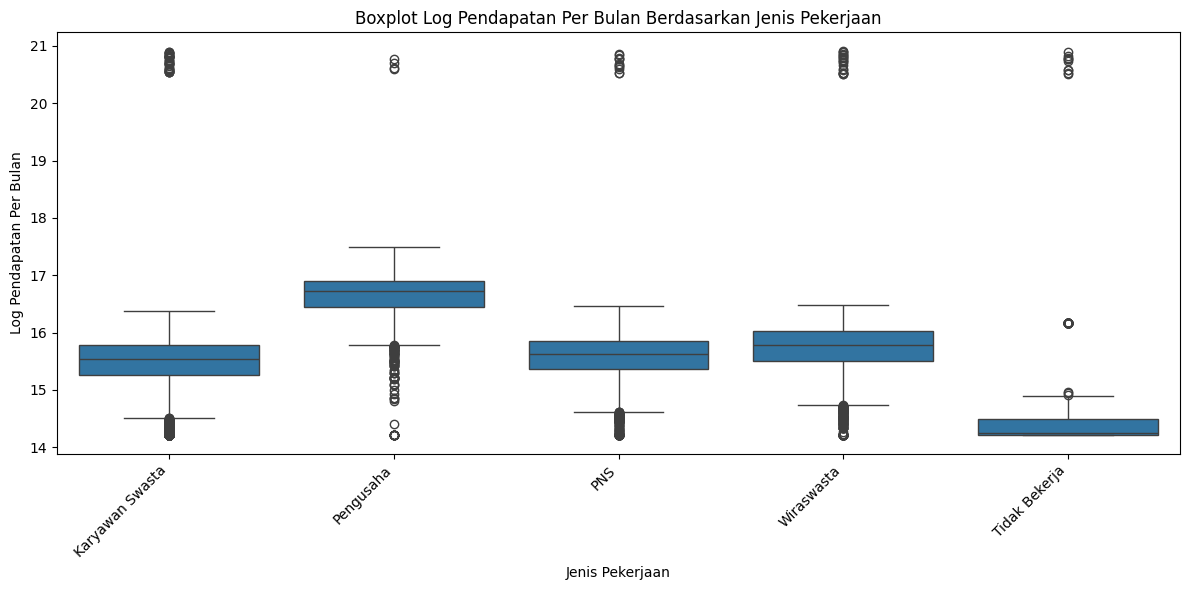

In [24]:
import seaborn as sns
#buat boxplot pendapatan per bulan berdasarkan jenis pekerjaan setelah transformasi log
plt.figure(figsize=(12, 6))
sns.boxplot(x="jenis_pekerjaan", y="log_pendapatan_per_b", data=df)
plt.title("Boxplot Log Pendapatan Per Bulan Berdasarkan Jenis Pekerjaan")
plt.xlabel("Jenis Pekerjaan")
plt.ylabel("Log Pendapatan Per Bulan")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [25]:
#lihat skewness log pendapatan per bulan berdasarkan jenis pekerjaan
skewness_by_job = df.groupby("jenis_pekerjaan")["log_pendapatan_per_b"].skew().reset_index(name="skewness")
print(skewness_by_job)

   jenis_pekerjaan  skewness
0  Karyawan Swasta  3.490678
1              PNS  2.989092
2        Pengusaha -0.339112
3    Tidak Bekerja  5.908453
4       Wiraswasta  3.006178


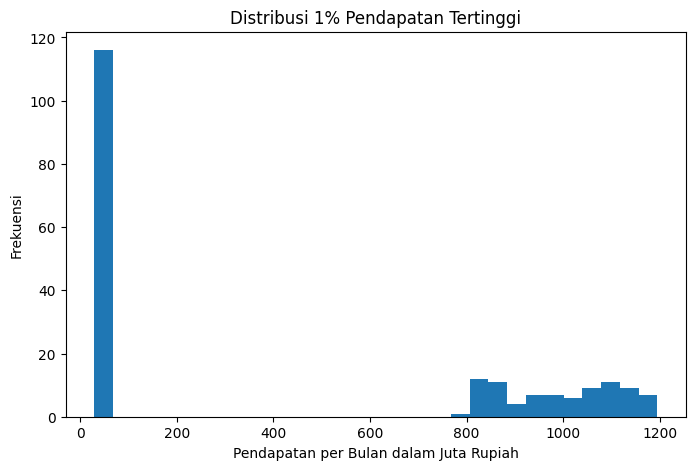

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(
    data_ekstrem["pendapatan_per_b"] / 1_000_000,
    bins=30
)
plt.xlabel("Pendapatan per Bulan dalam Juta Rupiah")
plt.ylabel("Frekuensi")
plt.title("Distribusi 1% Pendapatan Tertinggi")
plt.show()

Skewness sebelum capping: 1.3843058524568594
Skewness setelah capping: -0.10888943938604302


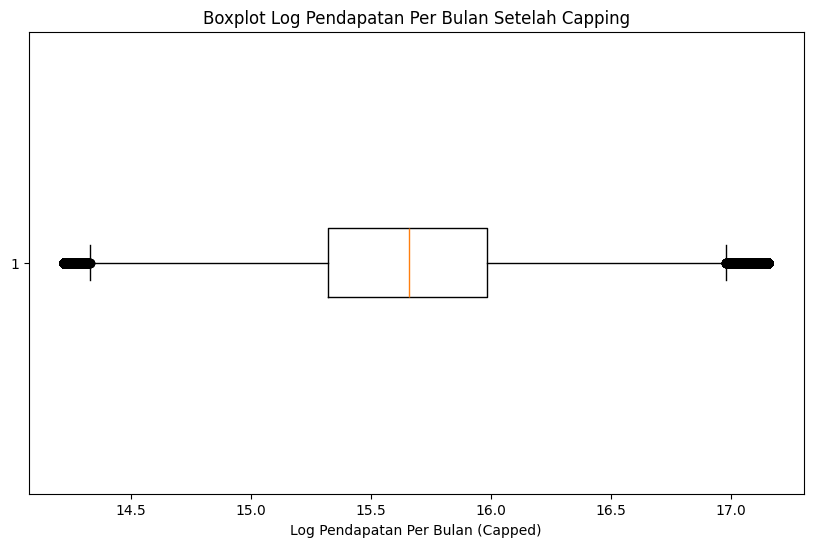

In [50]:
p1 = df["log_pendapatan_per_b"].quantile(0.01)
p99 = df["log_pendapatan_per_b"].quantile(0.99)

df["log_pendapatan_per_b_cap"] = df["log_pendapatan_per_b"].clip(p1, p99)
print(f"Skewness sebelum capping: {df['log_pendapatan_per_b'].skew()}")
print(f"Skewness setelah capping: {df['log_pendapatan_per_b_cap'].skew()}")
plt.figure(figsize=(10, 6))
plt.boxplot(df['log_pendapatan_per_b_cap'], vert=False)
plt.title('Boxplot Log Pendapatan Per Bulan Setelah Capping')
plt.xlabel('Log Pendapatan Per Bulan (Capped)')
plt.show()

##### Jadi pengisian missing value kolom pendapatan per bulan menggunakan transform log dan caping

In [51]:
#melihat skewness semua kolom
skewness_all = df.select_dtypes(include="number").skew().reset_index(name="skewness")
print(skewness_all)

                       index   skewness
0                       usia   0.218724
1           jumlah_tanggunga   0.666135
2           pendapatan_per_b  15.521870
3           lama_bekerja_tah   0.637974
4           jumlah_kredit_ak   1.385690
5               total_kredit   8.115277
6           sisa_bayar_kredi  10.470597
7                tenor_bulan   1.063442
8            bunga_per_tahun   0.007828
9           cicilan_per_bula  22.597350
10          rasio_utang_pend  68.423190
11                is_default   1.500113
12          jumlah_tunggakan   2.096281
13          skor_kredit_sebe  -1.373396
14      log_pendapatan_per_b   1.384306
15  log_pendapatan_per_b_cap  -0.108889


In [52]:
df["rasio_hitung_ulang"] = (
    df["cicilan_per_bula"] /
    df["pendapatan_per_b"]
)

In [66]:
df["selisih_rasio"] = abs(
    df["rasio_utang_pend"] -
    df["rasio_hitung_ulang"]
)

df[
    [
        "pendapatan_per_b",
        "jenis_pekerjaan",
        "nama",
        "pendidikan",
        "total_kredit",
        "cicilan_per_bula",
        "rasio_utang_pend",
        "rasio_hitung_ulang",
        "selisih_rasio",
        "is_default"
    ]
].sort_values(
    "selisih_rasio",
    ascending=False
).head(20)

,pendapatan_per_b,jenis_pekerjaan,nama,pendidikan,total_kredit,cicilan_per_bula,rasio_utang_pend,rasio_hitung_ulang,selisih_rasio,is_default
11555,1500000.0,Tidak Bekerja,Zahra Wahyudi,SMA,3.495461e+09,377656598,2.5,251.771065,249.271065,1
14135,3615136.0,Karyawan Swasta,Gilang Maharani,S1,4.558190e+09,801303809,2.5,221.652466,219.152466,0
7216,2133683.0,Karyawan Swasta,Kartika Rahayu,Diploma,4.132906e+09,388077785,2.5,181.881650,179.381650,0
4862,2392137.0,Karyawan Swasta,Fajar Qodir,S1,4.741239e+09,399763601,2.5,167.115680,164.615680,0
6985,3440685.0,Karyawan Swasta,Joko Gunawan,SMA,2.338668e+09,406334526,2.5,118.096985,115.596985,0
5323,1730456.0,Karyawan Swasta,Dewi Nugroho,S2,3.107764e+09,195167095,2.5,112.783622,110.283622,1
505,1500000.0,Karyawan Swasta,Agus Susanto,S1,4.528824e+09,156559357,2.5,104.372905,101.872905,0
20193,1500000.0,Tidak Bekerja,Andi Qodir,SMA,4.676286e+09,150514506,2.5,100.343004,97.843004,1
3194,1500000.0,Tidak Bekerja,Erna Purnama,S1,4.516760e+09,144156040,2.5,96.104027,93.604027,1
14781,2339644.0,Karyawan Swasta,Sari Wibowo,S2,2.027555e+09,211926111,2.5,90.580495,88.080495,1


In [ ]:
#tampilkan berapa banyak yang selisih rasio lebih dari 0.1
selisih_besar = df[df["selisih_rasio"] > 0.5]
print(f"Jumlah nasabah dengan selisih rasio lebih dari 0.1: {len(selisih_besar)}")

### Handling Outliers Total Kredit

Langkah 1: cek ringkasan awal total kredit
count    2.000000e+04
mean     1.952940e+08
std      3.617380e+08
min      5.000000e+06
25%      4.804696e+07
50%      8.636674e+07
75%      2.816713e+08
max      4.992338e+09
Name: total_kredit, dtype: float64

Langkah 2: hitung batas outlier dengan metode IQR
Q1         : 48046959.25
Q3         : 281671258.00
IQR        : 233624298.75
Batas bawah: -302389488.88
Batas atas : 632107706.12

Langkah 3: hitung jumlah data outlier
Jumlah outlier: 339
Persentase outlier: 1.70%

Contoh 10 data outlier terbesar:
       total_kredit
13050  4.992338e+09
14093  4.978201e+09
13219  4.972674e+09
5193   4.970967e+09
17673  4.929869e+09
5057   4.926788e+09
15190  4.923196e+09
12145  4.918008e+09
13112  4.887263e+09
17055  4.864607e+09

Langkah 4: handling outlier dengan capping/winsorizing

Langkah 5: bandingkan ringkasan sebelum dan sesudah handling
            sebelum       sesudah
count  2.000000e+04  2.000000e+04
mean   1.952940e+08  1.698271e+08
std   

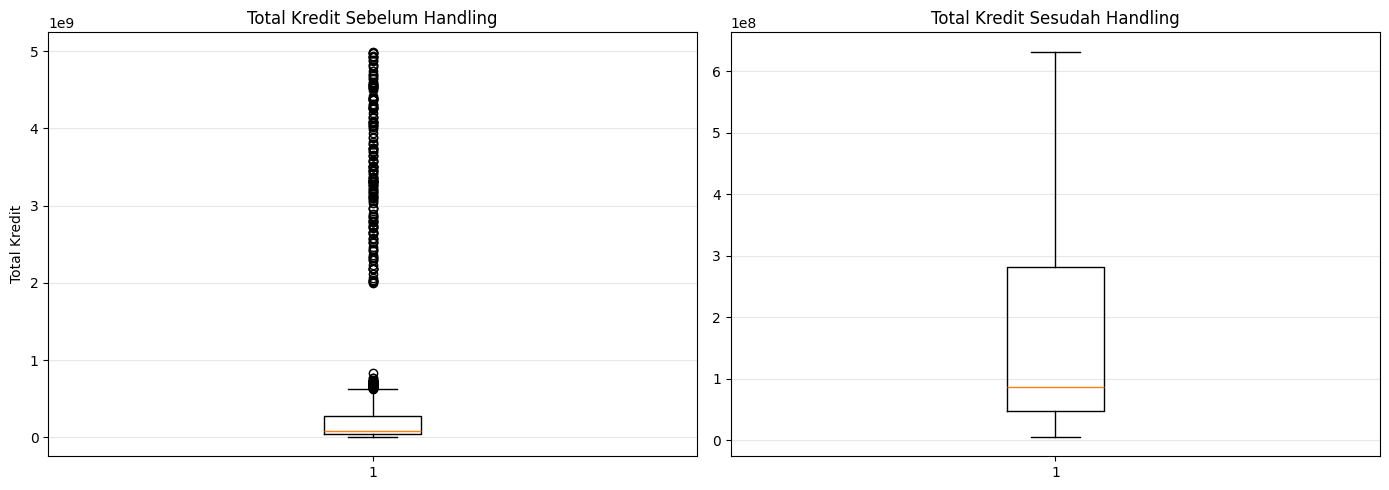


Hasil akhir: kolom total_kredit_handled sudah berisi nilai total kredit yang sudah di-capping.


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

kolom = "total_kredit"

print("Langkah 1: cek ringkasan awal total kredit")
ringkasan_awal = df[kolom].describe()
print(ringkasan_awal)

print("\nLangkah 2: hitung batas outlier dengan metode IQR")
q1 = df[kolom].quantile(0.25)
q3 = df[kolom].quantile(0.75)
iqr = q3 - q1
batas_bawah = q1 - 1.5 * iqr
batas_atas = q3 + 1.5 * iqr

print(f"Q1         : {q1:.2f}")
print(f"Q3         : {q3:.2f}")
print(f"IQR        : {iqr:.2f}")
print(f"Batas bawah: {batas_bawah:.2f}")
print(f"Batas atas : {batas_atas:.2f}")

print("\nLangkah 3: hitung jumlah data outlier")
mask_outlier = (df[kolom] < batas_bawah) | (df[kolom] > batas_atas)
jumlah_outlier = int(mask_outlier.sum())
persen_outlier = jumlah_outlier / df[kolom].notna().sum() * 100
print(f"Jumlah outlier: {jumlah_outlier}")
print(f"Persentase outlier: {persen_outlier:.2f}%")

print("\nContoh 10 data outlier terbesar:")
print(df.loc[mask_outlier, [kolom]].sort_values(kolom, ascending=False).head(10))

print("\nLangkah 4: handling outlier dengan capping/winsorizing")
df["total_kredit_handled"] = df[kolom].clip(lower=batas_bawah, upper=batas_atas)

print("\nLangkah 5: bandingkan ringkasan sebelum dan sesudah handling")
perbandingan = pd.DataFrame({
    "sebelum": df[kolom].describe(),
    "sesudah": df["total_kredit_handled"].describe(),
})
print(perbandingan)

print("\nLangkah 6: visualisasi boxplot sebelum dan sesudah")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df[kolom].dropna(), vert=True)
axes[0].set_title("Total Kredit Sebelum Handling")
axes[0].set_ylabel("Total Kredit")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(df["total_kredit_handled"].dropna(), vert=True)
axes[1].set_title("Total Kredit Sesudah Handling")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHasil akhir: kolom total_kredit_handled sudah berisi nilai total kredit yang sudah di-capping.")

Metode yang dipakai: IQR
Jumlah outlier: 339 data
Persentase outlier: 1.70%
Batas atas outlier: 632,107,706.12
Setelah capping, nilai maksimum total_kredit turun dari 4.99e9 menjadi 6.32e8

### Lihat semua boxplot kolom

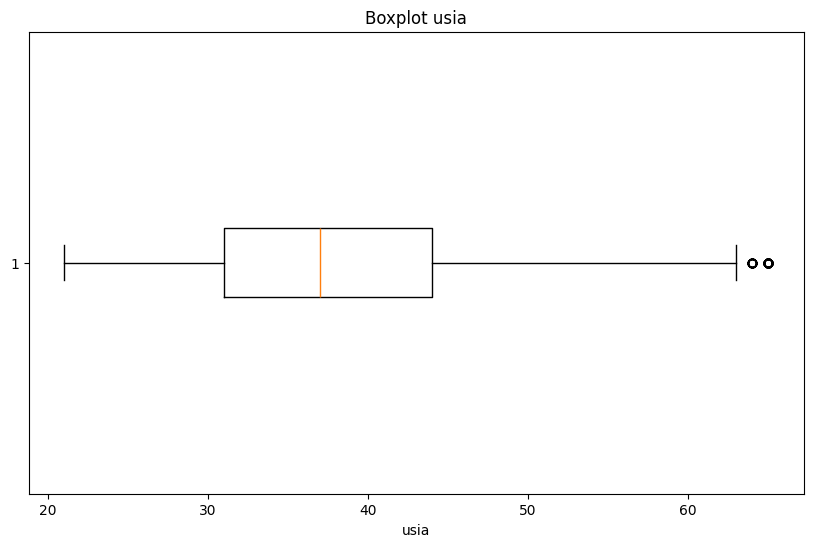

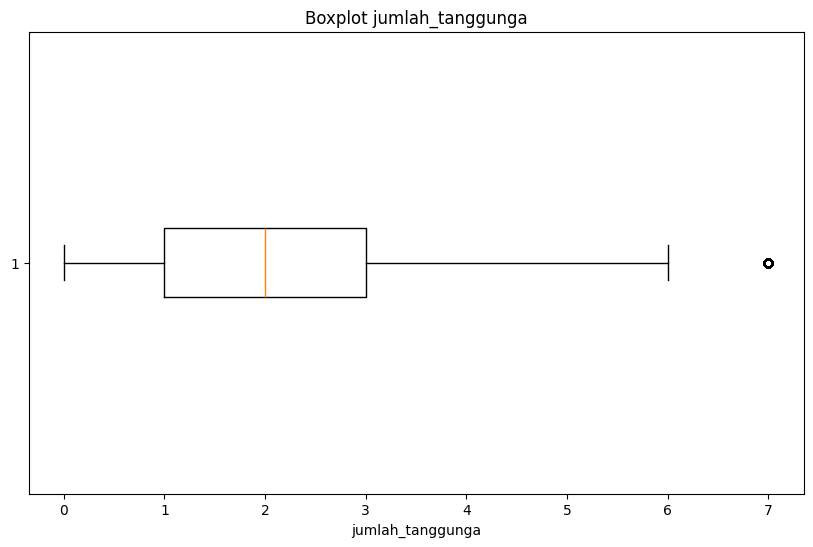

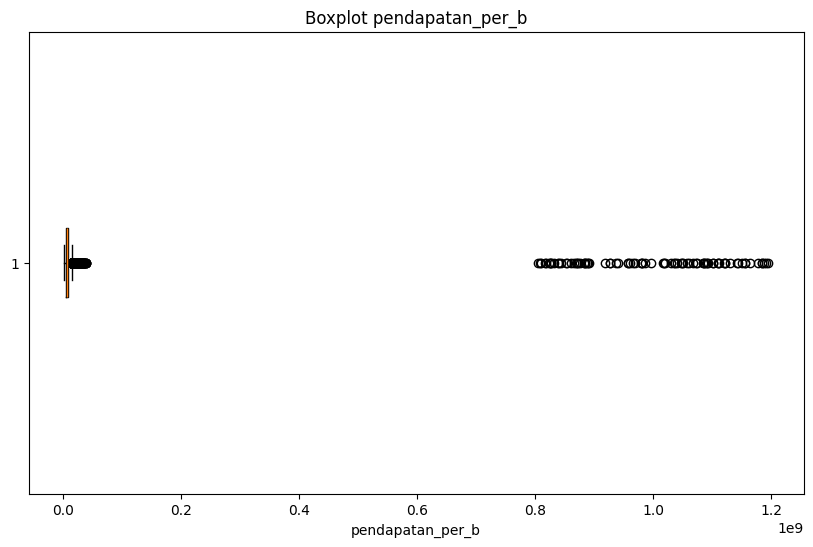

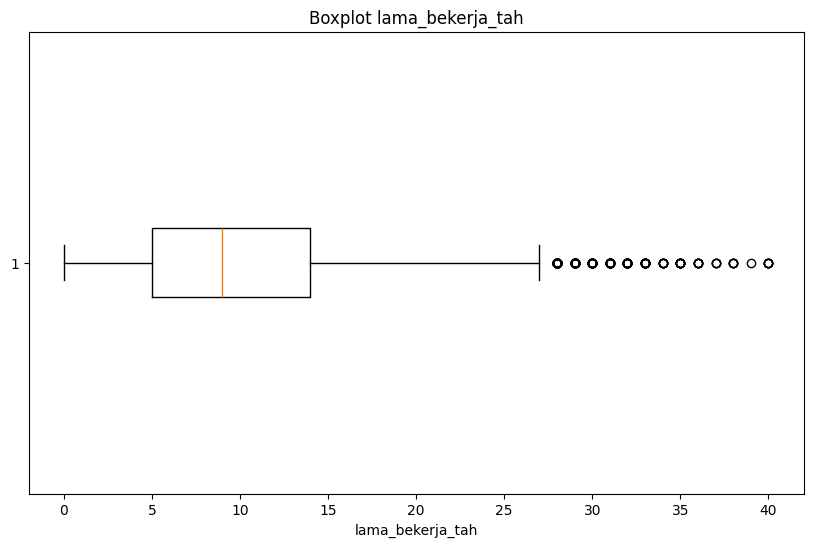

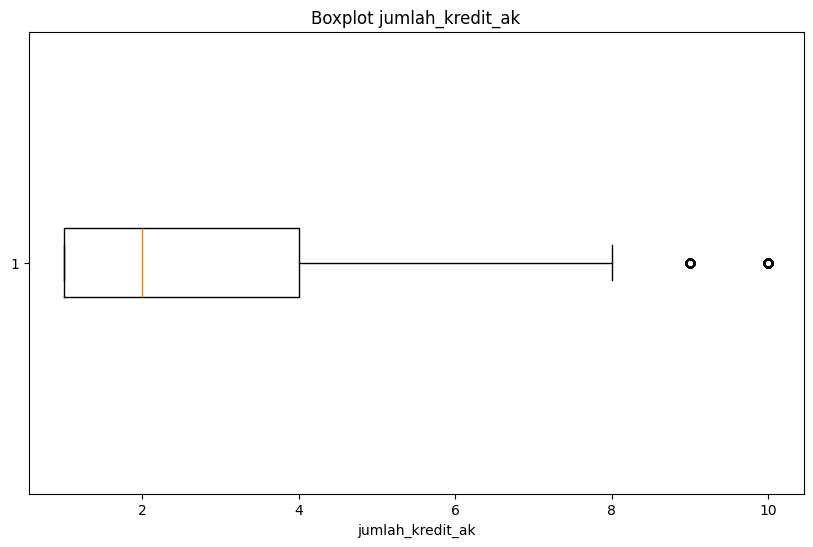

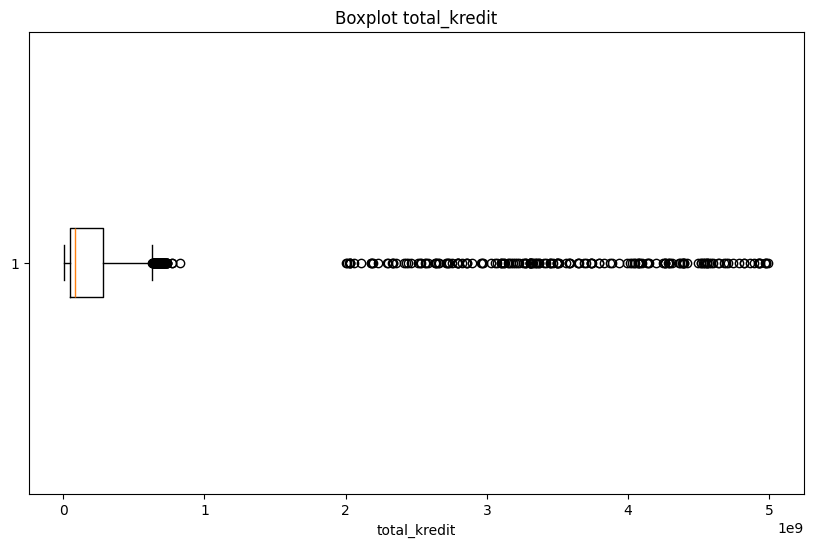

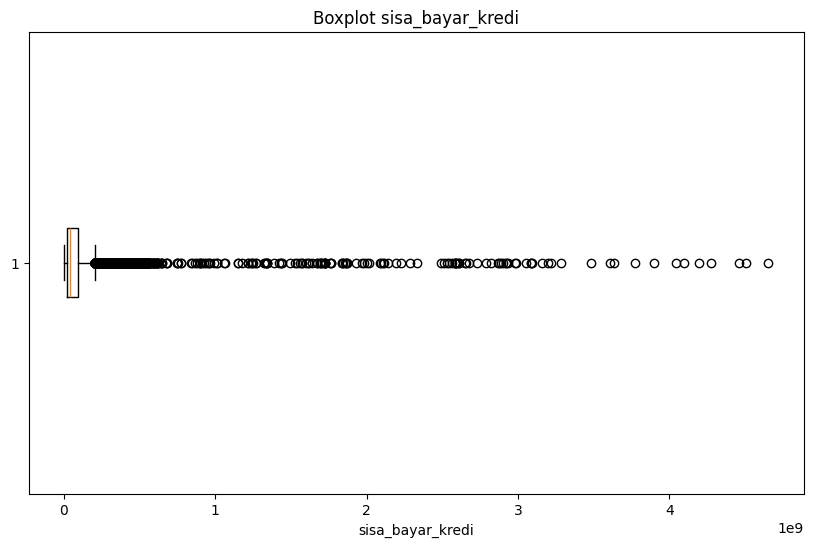

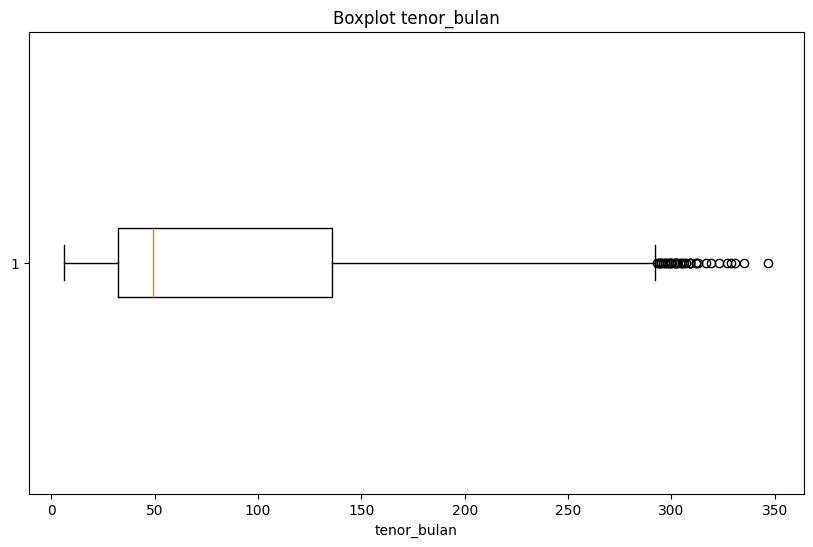

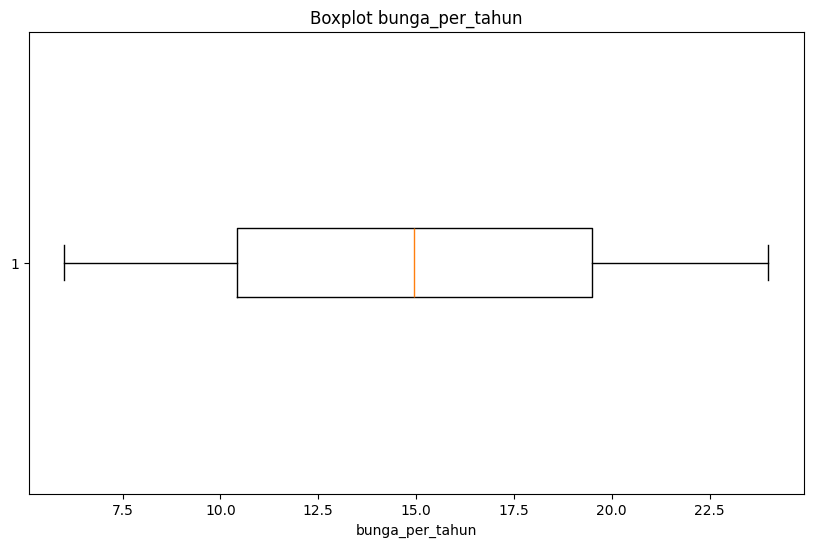

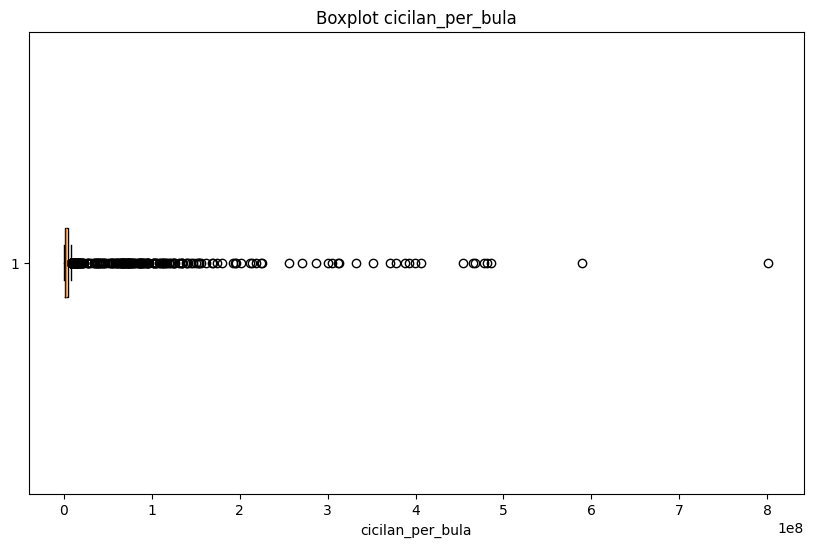

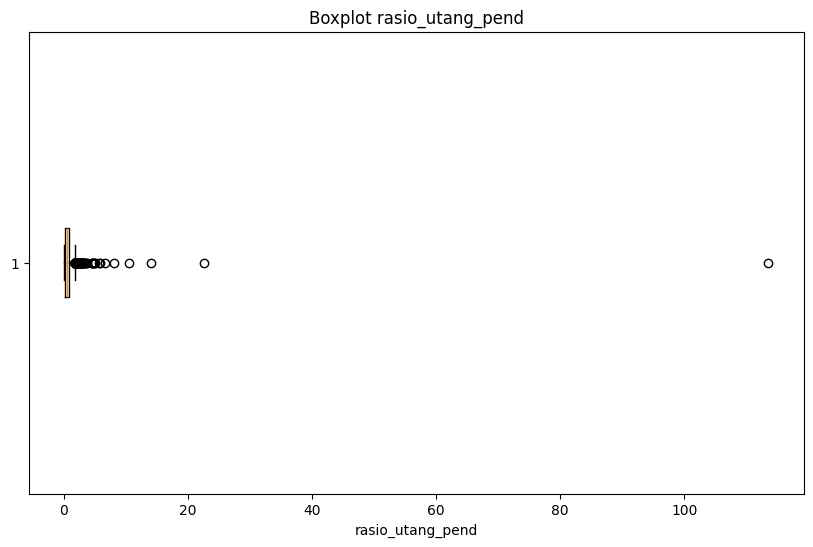

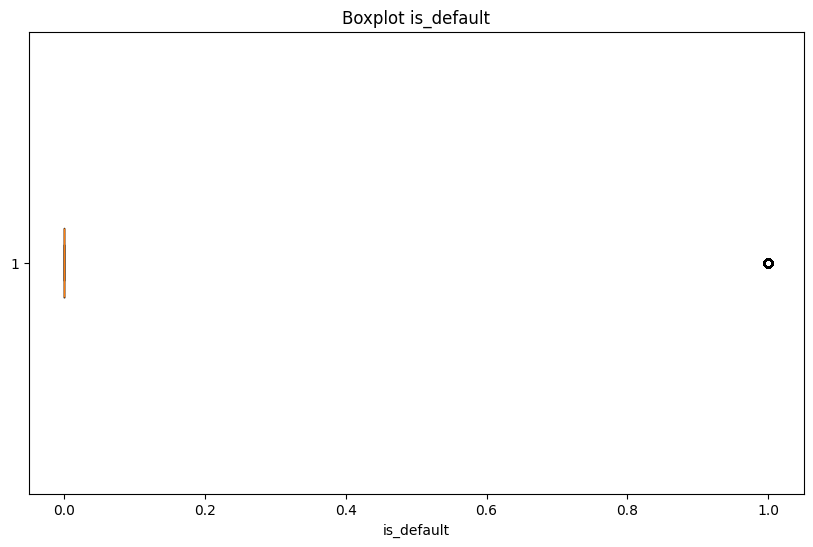

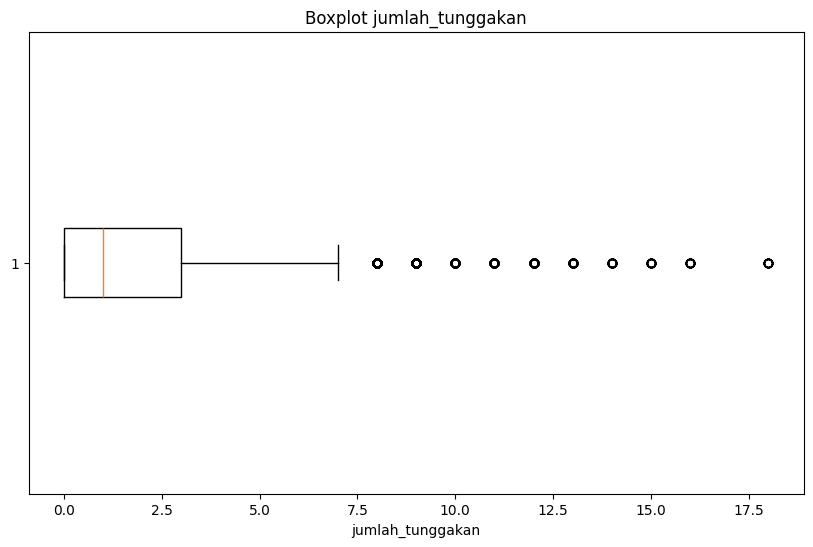

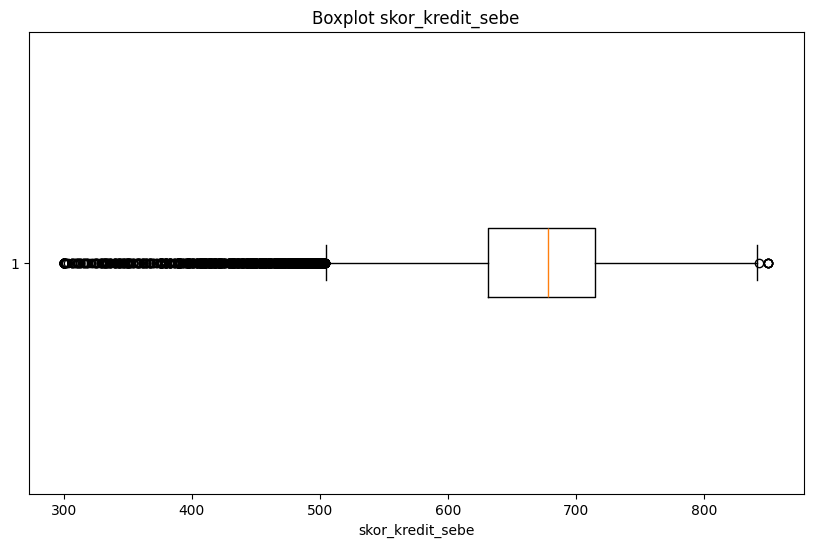

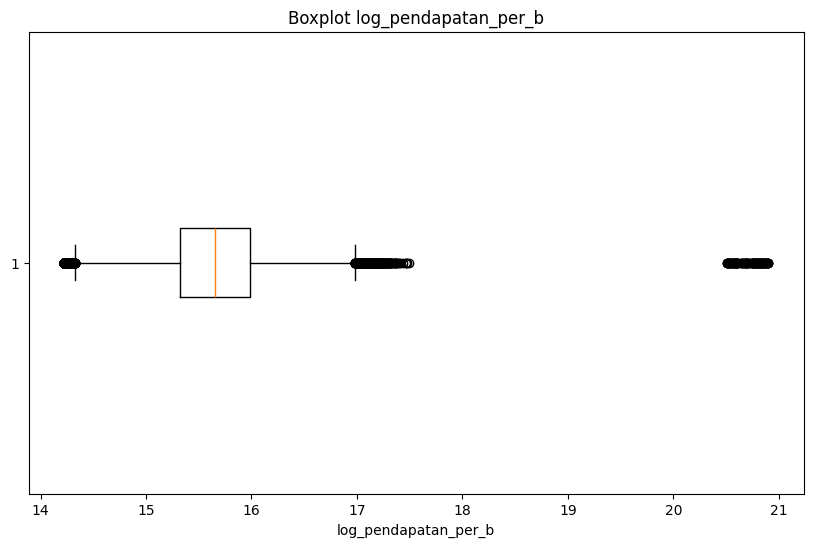

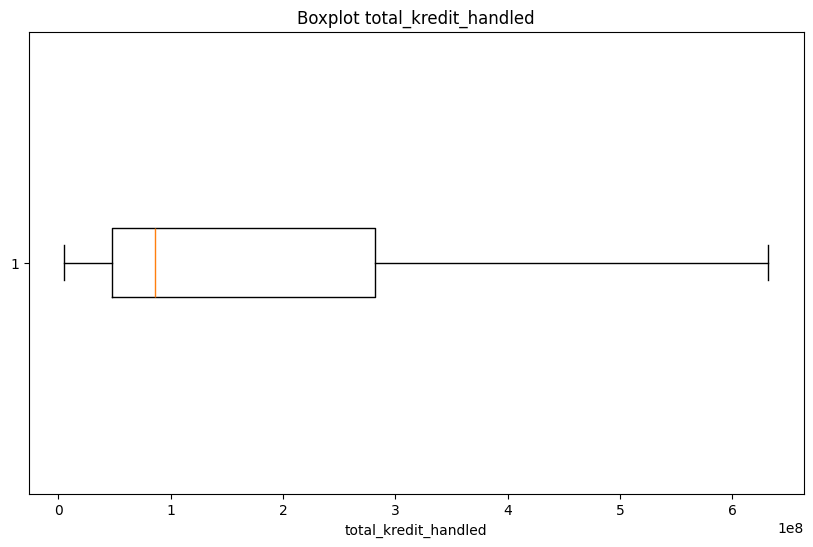

In [30]:
#tampilkan boxplot untuk tiap kolom
kolom_numerik = df.select_dtypes(include="number").columns.tolist()
for kolom in kolom_numerik:
    plt.figure(figsize=(10, 6))
    plt.boxplot(df[kolom].dropna(), vert=False)
    plt.title(f'Boxplot {kolom}')
    plt.xlabel(kolom)
    plt.show()
    

### Handling Outliers Lama Bekerja

Langkah 1: cek ringkasan awal lama bekerja
count    20000.000000
mean         9.807350
std          6.838126
min          0.000000
25%          5.000000
50%          9.000000
75%         14.000000
max         40.000000
Name: lama_bekerja_tah, dtype: float64

Langkah 2: analisis kandidat metode
Q1         : 5.00
Q3         : 14.00
IQR        : 9.00
Batas atas IQR : 27.50
P99            : 28.00
Outlier menurut IQR: 266
Nilai di atas P99   : 187
Pelanggaran batas logis usia - 15: 0

Analisis metode:
- IQR cukup baik untuk deteksi outlier statistik, tetapi pada lama bekerja batas atasnya relatif rendah dan masih bisa menandai tenure panjang yang sebenarnya masuk akal.
- Karena tidak ada nilai negatif dan tidak ada pelanggaran batas logis usia, handling yang lebih aman adalah capping di ekor kanan dengan P99.
- Metode ini mempertahankan variasi data utama, tetapi mengurangi pengaruh nilai ekstrem yang sangat tinggi.

Langkah 3: handling outlier dengan capping P99
Jumlah data yang di-capping

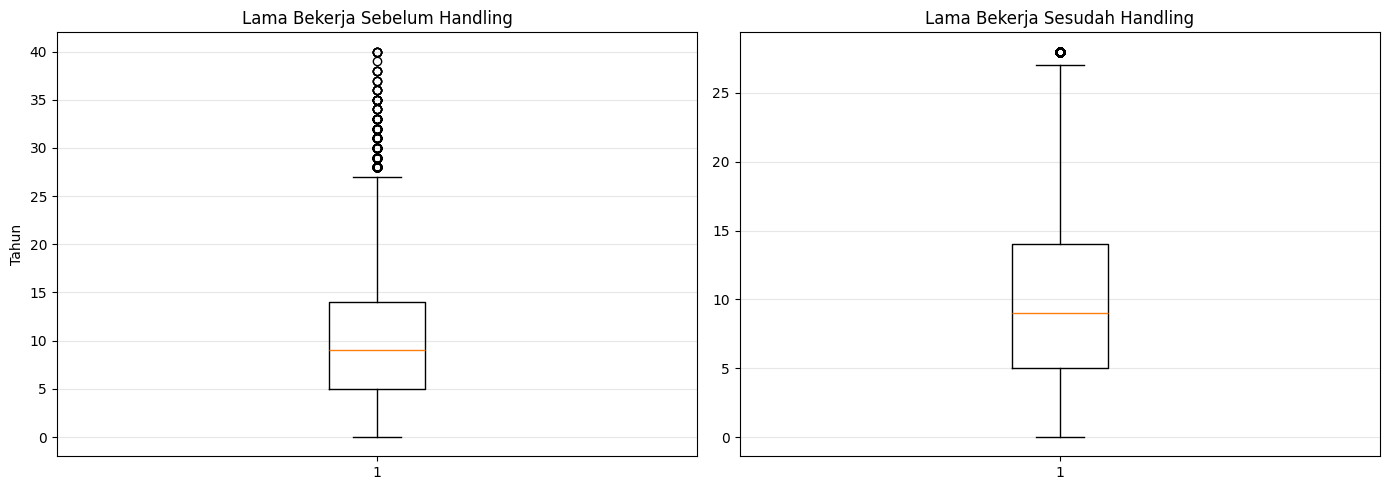


Hasil akhir: kolom lama_bekerja_handled berisi lama bekerja yang sudah di-capping pada P99.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

kolom = "lama_bekerja_tah"
s = df[kolom]

print("Langkah 1: cek ringkasan awal lama bekerja")
ringkasan_awal = s.describe()
print(ringkasan_awal)

print("\nLangkah 2: analisis kandidat metode")
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
batas_iqr = q3 + 1.5 * iqr
p99 = s.quantile(0.99)

print(f"Q1         : {q1:.2f}")
print(f"Q3         : {q3:.2f}")
print(f"IQR        : {iqr:.2f}")
print(f"Batas atas IQR : {batas_iqr:.2f}")
print(f"P99            : {p99:.2f}")
print(f"Outlier menurut IQR: {int((s > batas_iqr).sum())}")
print(f"Nilai di atas P99   : {int((s > p99).sum())}")

if "usia" in df.columns:
    batas_logis = df["usia"] - 15
    pelanggaran_logis = int((s > batas_logis).sum())
    print(f"Pelanggaran batas logis usia - 15: {pelanggaran_logis}")
else:
    pelanggaran_logis = 0

print("\nAnalisis metode:")
print("- IQR cukup baik untuk deteksi outlier statistik, tetapi pada lama bekerja batas atasnya relatif rendah dan masih bisa menandai tenure panjang yang sebenarnya masuk akal.")
print("- Karena tidak ada nilai negatif dan tidak ada pelanggaran batas logis usia, handling yang lebih aman adalah capping di ekor kanan dengan P99.")
print("- Metode ini mempertahankan variasi data utama, tetapi mengurangi pengaruh nilai ekstrem yang sangat tinggi.")

print("\nLangkah 3: handling outlier dengan capping P99")
df["lama_bekerja_handled"] = s.clip(lower=0, upper=p99)

jumlah_tercap = int((s > p99).sum())
print(f"Jumlah data yang di-capping: {jumlah_tercap}")
print("Contoh nilai sebelum dan sesudah:")
contoh = pd.DataFrame({
    "sebelum": s[s > p99].sort_values(ascending=False).head(10),
})
contoh["sesudah"] = contoh["sebelum"].clip(upper=p99)
print(contoh)

print("\nLangkah 4: bandingkan ringkasan sebelum dan sesudah")
perbandingan = pd.DataFrame({
    "sebelum": s.describe(),
    "sesudah": df["lama_bekerja_handled"].describe(),
})
print(perbandingan)

print("\nLangkah 5: visualisasi boxplot sebelum dan sesudah")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(s.dropna(), vert=True)
axes[0].set_title("Lama Bekerja Sebelum Handling")
axes[0].set_ylabel("Tahun")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(df["lama_bekerja_handled"].dropna(), vert=True)
axes[1].set_title("Lama Bekerja Sesudah Handling")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHasil akhir: kolom lama_bekerja_handled berisi lama bekerja yang sudah di-capping pada P99.")

Metode yang dipakai: IQR
Jumlah outlier: 339 data
Persentase outlier: 1.70%
Batas atas outlier: 632,107,706.12
Setelah capping, nilai maksimum total_kredit turun dari 4.99e9 menjadi 6.32e8

### Handling Outliers Sisa Bayar Kredit

Langkah 1: cek ringkasan awal sisa bayar kredit
count    2.000000e+04
mean     9.429545e+07
std      2.055382e+08
min      2.645940e+05
25%      1.933792e+07
50%      4.095315e+07
75%      9.337083e+07
max      4.653899e+09
Name: sisa_bayar_kredi, dtype: float64
Nilai minimum: 264594.0
Nilai maksimum: 4653898716.0
Jumlah nilai negatif: 0
Jumlah nilai nol: 0

Langkah 2: data understanding dengan variabel terkait
Ringkasan rasio sisa_bayar_kredi / total_kredit
count    20000.000000
mean         0.510010
std          0.307700
min          0.009274
25%          0.275512
50%          0.504812
75%          0.724072
max          8.190629
dtype: float64
Korelasi dengan total_kredit: 0.8310
Korelasi dengan rasio_utang_pend: 0.3391
Jumlah nilai dengan rasio > 1: 209

Cek pola rasio berdasarkan bucket total_kredit
                             rata_total_kredit  rata_sisa_bayar  rata_rasio  \
bucket_total_kredit                                                           
(4999999.999, 48046959.25] 

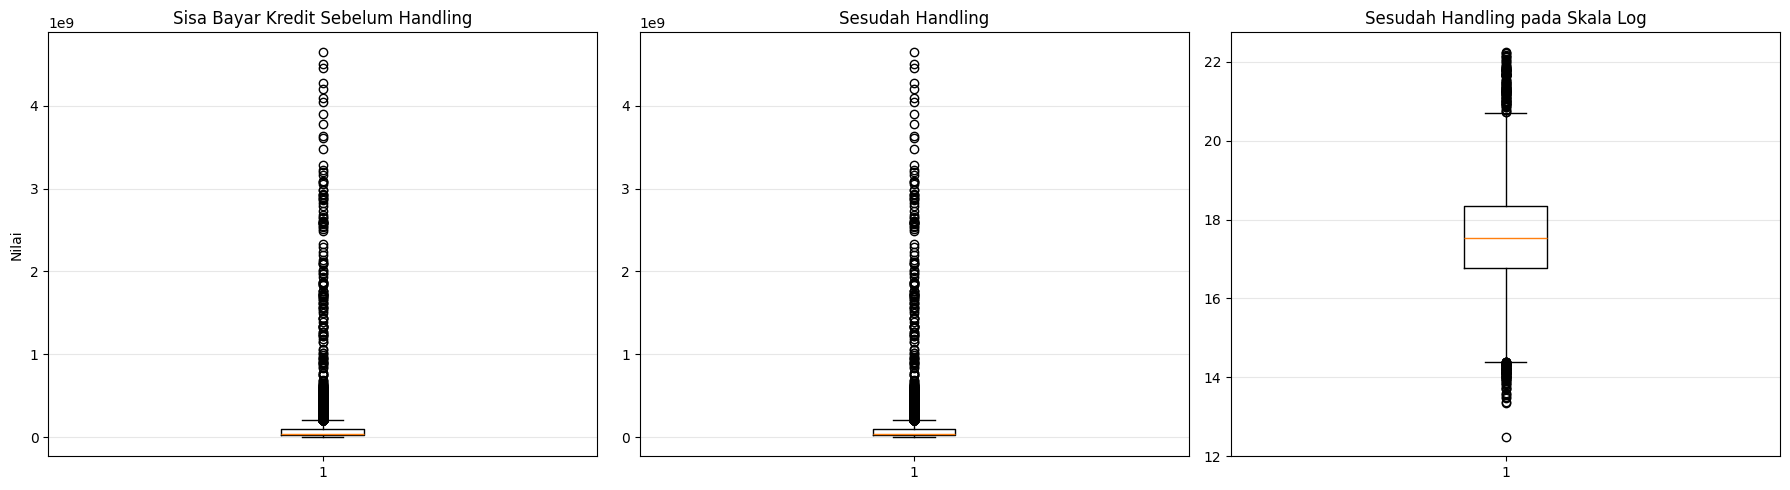


Hasil akhir: kolom sisa_bayar_kredi_handled sudah dibatasi oleh rasio maksimum 1 terhadap total_kredit.


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

kolom = "sisa_bayar_kredi"
s = df[kolom]

print("Langkah 1: cek ringkasan awal sisa bayar kredit")
ringkasan_awal = s.describe()
print(ringkasan_awal)
print("Nilai minimum:", s.min())
print("Nilai maksimum:", s.max())
print("Jumlah nilai negatif:", int((s < 0).sum()))
print("Jumlah nilai nol:", int((s == 0).sum()))

print("\nLangkah 2: data understanding dengan variabel terkait")
if "total_kredit" in df.columns:
    total_kredit_nonzero = df["total_kredit"].replace(0, np.nan)
    ratio = s / total_kredit_nonzero
    print("Ringkasan rasio sisa_bayar_kredi / total_kredit")
    print(ratio.describe())
    print(f"Korelasi dengan total_kredit: {s.corr(df['total_kredit']):.4f}")
    if "rasio_utang_pend" in df.columns:
        print(f"Korelasi dengan rasio_utang_pend: {s.corr(df['rasio_utang_pend']):.4f}")
    print(f"Jumlah nilai dengan rasio > 1: {int((ratio > 1).sum())}")

    print("\nCek pola rasio berdasarkan bucket total_kredit")
    df["bucket_total_kredit"] = pd.qcut(df["total_kredit"], q=4, duplicates="drop")
    pola_bucket = df.groupby("bucket_total_kredit", observed=True).agg(
        rata_total_kredit=("total_kredit", "mean"),
        rata_sisa_bayar=(kolom, "mean"),
        rata_rasio=(kolom, lambda x: (x / df.loc[x.index, "total_kredit"]).mean()),
        prop_rasio_gt_1=(kolom, lambda x: ((x / df.loc[x.index, "total_kredit"]) > 1).mean()),
    )
    print(pola_bucket)

    print("\nContoh 10 nilai terbesar:")
    print(df[[kolom, "total_kredit"]].sort_values(kolom, ascending=False).head(10))
else:
    ratio = None
    total_kredit_nonzero = None
    print("Kolom total_kredit tidak tersedia, jadi analisis konteks tidak bisa dipakai.")

print("\nAnalisis metode:")
print("- sisa_bayar_kredi sangat bergantung pada total_kredit, jadi outlier harus dibaca sebagai masalah rasio terhadap kredit, bukan hanya nilai absolut.")
print("- Karena sisa bayar tidak logis jika melebihi total kredit, handling yang dipakai adalah capping rasio pada 1.0 per baris.")
print("- Untuk visualisasi, boxplot raw tetap akan terlihat padat di ekor kanan, jadi saya tambahkan boxplot pada skala log agar bentuk distribusinya lebih terbaca.")

print("\nLangkah 3: handling outlier dengan batas logis rasio")
if total_kredit_nonzero is not None:
    df["rasio_sisa_bayar"] = s / total_kredit_nonzero
    df["rasio_sisa_bayar_handled"] = df["rasio_sisa_bayar"].clip(lower=0, upper=1)
    df["sisa_bayar_kredi_handled"] = df["rasio_sisa_bayar_handled"] * df["total_kredit"]

    jumlah_tercap = int((df["rasio_sisa_bayar"] > 1).sum())
    print(f"Jumlah data yang di-capping: {jumlah_tercap}")
    print("Jumlah rasio > 1 sesudah handling:", int((df["rasio_sisa_bayar_handled"] > 1).sum()))

    if jumlah_tercap > 0:
        contoh = pd.DataFrame({
            "sebelum": df.loc[df["rasio_sisa_bayar"] > 1, kolom].sort_values(ascending=False).head(10),
            "total_kredit": df.loc[df["rasio_sisa_bayar"] > 1, "total_kredit"].head(10),
        })
        contoh["sesudah"] = contoh[["sebelum", "total_kredit"]].min(axis=1)
        contoh["rasio_sebelum"] = contoh["sebelum"] / contoh["total_kredit"]
        contoh["rasio_sesudah"] = contoh["sesudah"] / contoh["total_kredit"]
        print("Contoh data sebelum dan sesudah:")
        print(contoh)
else:
    df["sisa_bayar_kredi_handled"] = s.copy()

print("\nLangkah 4: bandingkan ringkasan sebelum dan sesudah")
perbandingan = pd.DataFrame({
    "sebelum": s.describe(),
    "sesudah": df["sisa_bayar_kredi_handled"].describe(),
})
print(perbandingan)

if total_kredit_nonzero is not None:
    ratio_sesudah = df["sisa_bayar_kredi_handled"] / total_kredit_nonzero
    print("\nRingkasan rasio sesudah handling")
    print(ratio_sesudah.describe())
    print("Jumlah rasio > 1 sesudah handling:", int((ratio_sesudah > 1).sum()))

print("\nLangkah 5: visualisasi boxplot sebelum dan sesudah")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].boxplot(s.dropna(), vert=True)
axes[0].set_title("Sisa Bayar Kredit Sebelum Handling")
axes[0].set_ylabel("Nilai")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(df["sisa_bayar_kredi_handled"].dropna(), vert=True)
axes[1].set_title("Sesudah Handling")
axes[1].grid(axis="y", alpha=0.3)

log_handled = np.log1p(df["sisa_bayar_kredi_handled"].dropna())
axes[2].boxplot(log_handled, vert=True)
axes[2].set_title("Sesudah Handling pada Skala Log")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHasil akhir: kolom sisa_bayar_kredi_handled sudah dibatasi oleh rasio maksimum 1 terhadap total_kredit.")

#### Pendekatan Tambahan: Log Transform + Capping

Langkah 6: log transform pada sisa_bayar_kredi_handled
count    20000.000000
mean        17.561716
std          1.240343
min         12.485956
25%         16.767913
50%         17.527939
75%         18.352089
max         22.260971
Name: log_sisa_bayar_kredi, dtype: float64
Skewness log sebelum capping: 0.06237476730194887

Langkah 7: winsorizing pada skala log dengan IQR
Q1 log         : 16.7679
Q3 log         : 18.3521
IQR log        : 1.5842
Batas bawah log: 14.3916
Batas atas log : 20.7284
Jumlah outlier pada skala log: 204

Ringkasan sesudah log capping
count    20000.000000
mean        17.558885
std          1.223910
min         14.391649
25%         16.767913
50%         17.527939
75%         18.352089
max         20.728354
Name: log_sisa_bayar_kredi_cap, dtype: float64
Skewness log sesudah capping: 0.0077223876856451915
Jumlah outlier log sesudah capping: 0

Perbandingan ringkasan skala asli
       handled_ratio_cap  logcap_backtransform
count       2.000000e+04          2.00000

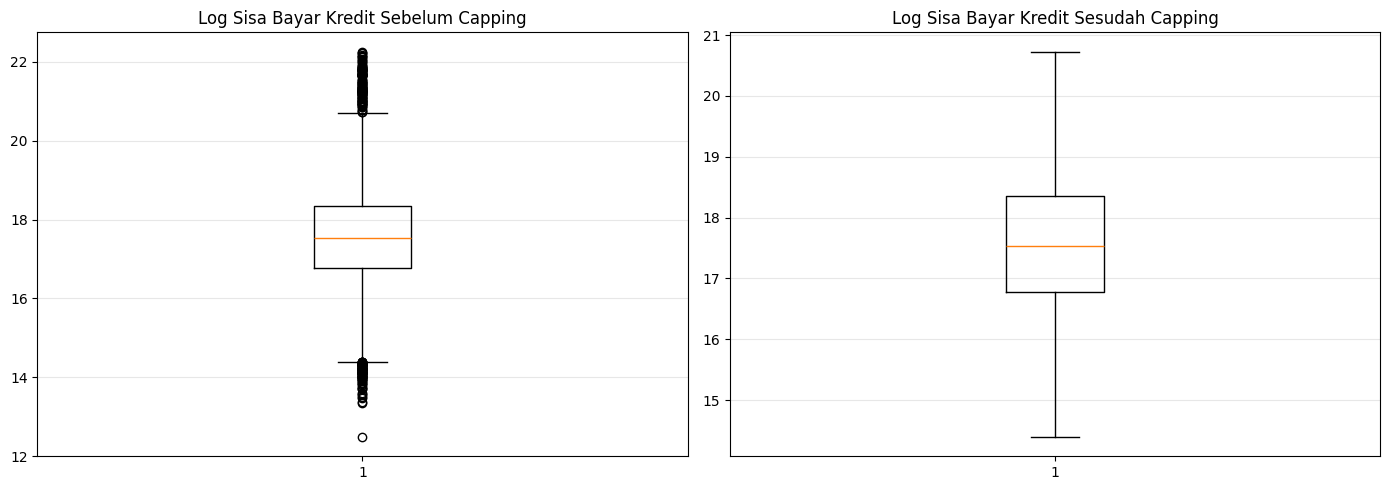


Hasil akhir: kolom sisa_bayar_kredi_logcap menyimpan versi yang sudah di-log lalu di-capping pada skala log.


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Langkah 6: log transform pada sisa_bayar_kredi_handled")
df["log_sisa_bayar_kredi"] = np.log1p(df["sisa_bayar_kredi_handled"])
print(df["log_sisa_bayar_kredi"].describe())
print("Skewness log sebelum capping:", df["log_sisa_bayar_kredi"].skew())

print("\nLangkah 7: winsorizing pada skala log dengan IQR")
q1_log = df["log_sisa_bayar_kredi"].quantile(0.25)
q3_log = df["log_sisa_bayar_kredi"].quantile(0.75)
iqr_log = q3_log - q1_log
batas_bawah_log = q1_log - 1.5 * iqr_log
batas_atas_log = q3_log + 1.5 * iqr_log
print(f"Q1 log         : {q1_log:.4f}")
print(f"Q3 log         : {q3_log:.4f}")
print(f"IQR log        : {iqr_log:.4f}")
print(f"Batas bawah log: {batas_bawah_log:.4f}")
print(f"Batas atas log : {batas_atas_log:.4f}")

mask_log_outlier = (df["log_sisa_bayar_kredi"] < batas_bawah_log) | (df["log_sisa_bayar_kredi"] > batas_atas_log)
jumlah_log_outlier = int(mask_log_outlier.sum())
print(f"Jumlah outlier pada skala log: {jumlah_log_outlier}")

df["log_sisa_bayar_kredi_cap"] = df["log_sisa_bayar_kredi"].clip(lower=batas_bawah_log, upper=batas_atas_log)
df["sisa_bayar_kredi_logcap"] = np.expm1(df["log_sisa_bayar_kredi_cap"])

print("\nRingkasan sesudah log capping")
print(df["log_sisa_bayar_kredi_cap"].describe())
print("Skewness log sesudah capping:", df["log_sisa_bayar_kredi_cap"].skew())
print("Jumlah outlier log sesudah capping:", int(((df["log_sisa_bayar_kredi_cap"] < batas_bawah_log) | (df["log_sisa_bayar_kredi_cap"] > batas_atas_log)).sum()))

print("\nPerbandingan ringkasan skala asli")
print(pd.DataFrame({
    "handled_ratio_cap": df["sisa_bayar_kredi_handled"].describe(),
    "logcap_backtransform": df["sisa_bayar_kredi_logcap"].describe(),
}))

print("\nVisualisasi log sebelum dan sesudah capping")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df["log_sisa_bayar_kredi"].dropna(), vert=True)
axes[0].set_title("Log Sisa Bayar Kredit Sebelum Capping")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(df["log_sisa_bayar_kredi_cap"].dropna(), vert=True)
axes[1].set_title("Log Sisa Bayar Kredit Sesudah Capping")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHasil akhir: kolom sisa_bayar_kredi_logcap menyimpan versi yang sudah di-log lalu di-capping pada skala log.")

###

### Handling Outliers Tenor Bulan

Langkah 1: ringkasan awal tenor bulan
count    20000.000000
mean        80.940000
std         71.037968
min          6.000000
25%         32.000000
50%         49.000000
75%        136.000000
max        347.000000
Name: tenor_bulan, dtype: float64
Nilai minimum: 6
Nilai maksimum: 347
Jumlah nilai <= 0: 0
Jumlah nilai > 120: 5428
Jumlah tenor unik: 310

Langkah 2: data understanding dengan variabel lain
              count        mean  median  min  max
jenis_kredit                                     
KPR            6077  178.484285   179.0   22  347
Multiguna      2614   59.377200    59.0    9  108
KKB            4005   47.438951    48.0    7   92
KTA            4394   35.341830    35.0    6   68
Kartu Kredit   2910   11.564948    12.0    6   21
Korelasi dengan total_kredit: 0.37684861867399755
Korelasi dengan cicilan_per_bula: 0.03190686087927751
Korelasi dengan bunga_per_tahun: -0.009826861723506785

Pola tenor terbesar:
       tenor_bulan jenis_kredit  total_kredit  cicilan_per_bula

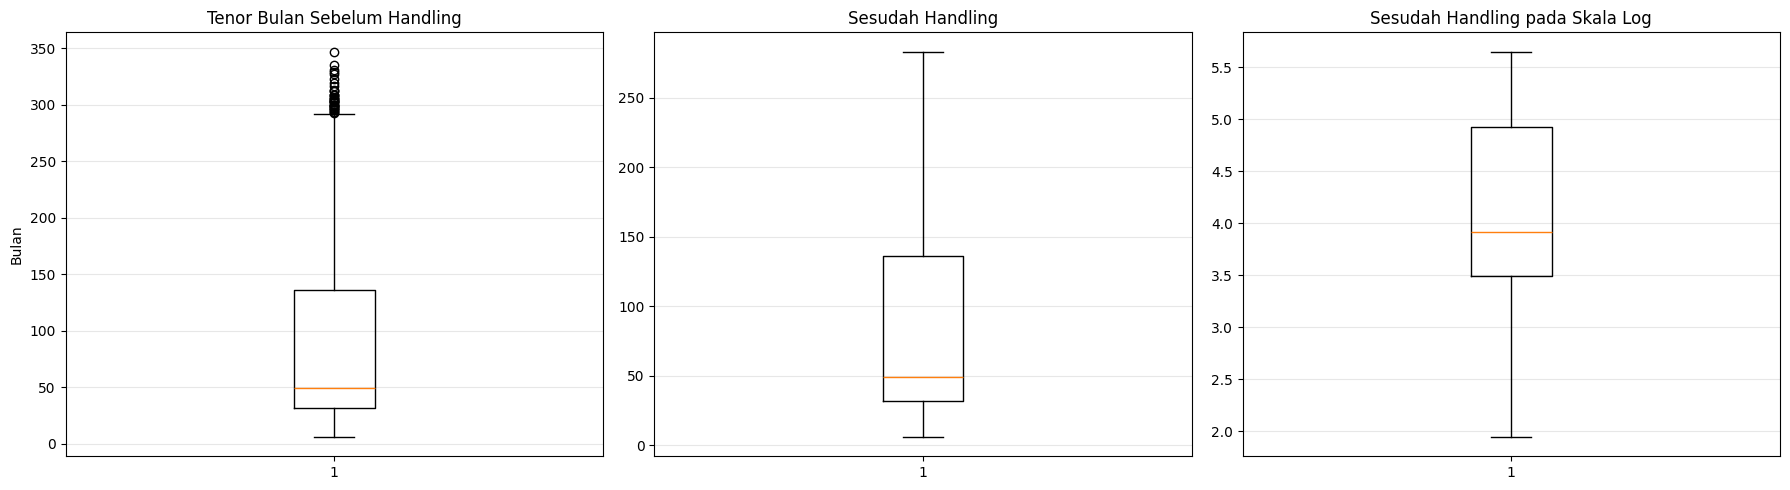


Hasil akhir: kolom tenor_bulan_handled sudah dibatasi per jenis_kredit menggunakan P99 kelompok masing-masing.


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

kolom = "tenor_bulan"
s = df[kolom]

print("Langkah 1: ringkasan awal tenor bulan")
print(s.describe())
print("Nilai minimum:", int(s.min()))
print("Nilai maksimum:", int(s.max()))
print("Jumlah nilai <= 0:", int((s <= 0).sum()))
print("Jumlah nilai > 120:", int((s > 120).sum()))
print("Jumlah tenor unik:", s.nunique())

print("\nLangkah 2: data understanding dengan variabel lain")
if "jenis_kredit" in df.columns:
    ringkasan_jenis = df.groupby("jenis_kredit")[kolom].agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    ).sort_values("median", ascending=False)
    print(ringkasan_jenis)

if "total_kredit" in df.columns:
    print("Korelasi dengan total_kredit:", float(s.corr(df["total_kredit"])))
if "cicilan_per_bula" in df.columns:
    print("Korelasi dengan cicilan_per_bula:", float(s.corr(df["cicilan_per_bula"])))
if "bunga_per_tahun" in df.columns:
    print("Korelasi dengan bunga_per_tahun:", float(s.corr(df["bunga_per_tahun"])))

print("\nPola tenor terbesar:")
print(df[[kolom] + [c for c in ["jenis_kredit", "total_kredit", "cicilan_per_bula", "bunga_per_tahun"] if c in df.columns]].sort_values(kolom, ascending=False).head(15))

q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
batas_atas = q3 + 1.5 * iqr
p95 = s.quantile(0.95)
p99 = s.quantile(0.99)
print("\nIQR analysis")
print(f"Q1         : {q1:.2f}")
print(f"Q3         : {q3:.2f}")
print(f"IQR        : {iqr:.2f}")
print(f"Batas atas : {batas_atas:.2f}")
print(f"Outlier IQR: {int((s > batas_atas).sum())}")
print(f"P95        : {p95:.2f}")
print(f"P99        : {p99:.2f}")
print(f"> P99      : {int((s > p99).sum())}")

print("\nAnalisis metode:")
print("- Tenor bulan tidak layak ditangani dengan capping global saja, karena distribusinya campuran antar jenis_kredit.")
print("- KPR memang punya tenor jauh lebih panjang daripada KTA, KKB, atau Kartu Kredit.")
print("- Maka handling yang paling tepat adalah capping per jenis_kredit memakai P99 masing-masing kelompok, dengan batas bawah 6 bulan.")

print("\nLangkah 3: handling outlier dengan capping per jenis_kredit")
if "jenis_kredit" in df.columns:
    batas_per_jenis = df.groupby("jenis_kredit")[kolom].quantile(0.99)
    df["tenor_bulan_handled"] = df[kolom].copy()

    for jenis, batas_jenis in batas_per_jenis.items():
        mask = df["jenis_kredit"] == jenis
        df.loc[mask, "tenor_bulan_handled"] = df.loc[mask, kolom].clip(lower=6, upper=batas_jenis).round().astype(int)

    jumlah_tercap = int((df["tenor_bulan_handled"] != df[kolom]).sum())
    print("Batas P99 per jenis_kredit:")
    print(batas_per_jenis)
    print(f"Jumlah data yang di-capping: {jumlah_tercap}")

    contoh = df.loc[df["tenor_bulan_handled"] != df[kolom], ["jenis_kredit", kolom, "tenor_bulan_handled"]].sort_values(kolom, ascending=False).head(15)
    print("Contoh data sebelum dan sesudah:")
    print(contoh)
else:
    df["tenor_bulan_handled"] = s.clip(lower=6, upper=p99)
    jumlah_tercap = int((df["tenor_bulan_handled"] != df[kolom]).sum())
    print(f"Jumlah data yang di-capping: {jumlah_tercap}")

print("\nLangkah 4: bandingkan ringkasan sebelum dan sesudah")
perbandingan = pd.DataFrame({
    "sebelum": s.describe(),
    "sesudah": df["tenor_bulan_handled"].describe(),
})
print(perbandingan)

if "jenis_kredit" in df.columns:
    print("\nRingkasan per jenis kredit sesudah handling")
    print(df.groupby("jenis_kredit")["tenor_bulan_handled"].agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    ).sort_values("median", ascending=False))

print("\nLangkah 5: visualisasi boxplot sebelum dan sesudah")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].boxplot(s.dropna(), vert=True)
axes[0].set_title("Tenor Bulan Sebelum Handling")
axes[0].set_ylabel("Bulan")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(df["tenor_bulan_handled"].dropna(), vert=True)
axes[1].set_title("Sesudah Handling")
axes[1].grid(axis="y", alpha=0.3)

log_tenor = np.log1p(df["tenor_bulan_handled"].dropna())
axes[2].boxplot(log_tenor, vert=True)
axes[2].set_title("Sesudah Handling pada Skala Log")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHasil akhir: kolom tenor_bulan_handled sudah dibatasi per jenis_kredit menggunakan P99 kelompok masing-masing.")

### Handling Outliers Cicilan Per Bulan

Langkah 1: cek ringkasan awal cicilan per bulan
count    2.000000e+04
mean     4.564497e+06
std      1.670816e+07
min      5.435700e+04
25%      1.783548e+06
50%      2.745775e+06
75%      4.577982e+06
max      8.013038e+08
Name: cicilan_per_bula, dtype: float64
Nilai minimum: 54357
Nilai maksimum: 801303809
Jumlah nilai <= 0: 0

Langkah 2: data understanding dengan variabel lain
Ringkasan rasio cicilan_per_bula / (total_kredit / tenor_bulan)
count    20000.000000
mean         1.625069
std          0.748287
min          1.000000
25%          1.148881
50%          1.331784
75%          1.752140
max          6.470685
dtype: float64
Jumlah rasio > 2: 3975
Jumlah rasio < 1: 0
Korelasi dengan total_kredit: 0.7004969243975299
Korelasi dengan tenor_bulan: 0.031906860879277514
Korelasi dengan bunga_per_tahun: 0.043676947347339616

Ringkasan per jenis_kredit
              count  mean_cicilan  median_cicilan  mean_tenor  \
jenis_kredit                                                    
KPR     

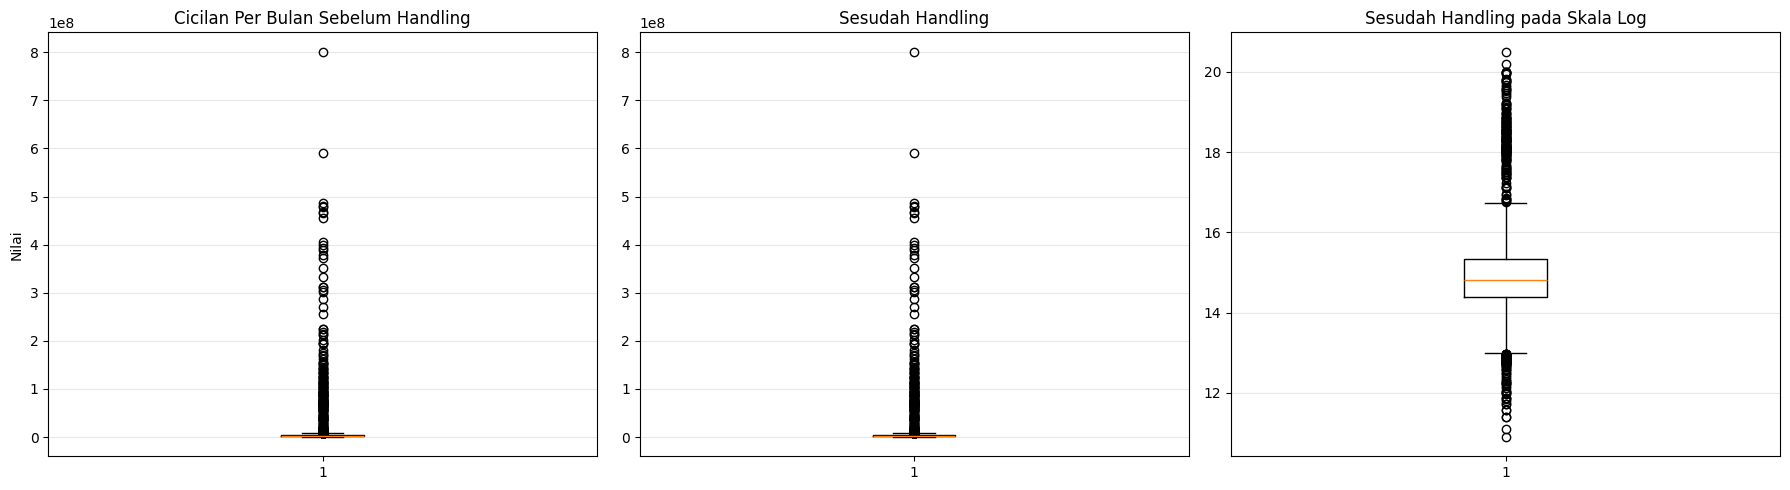


Hasil akhir: kolom cicilan_per_bula_handled sudah dibatasi berdasarkan rasio per jenis_kredit.


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

kolom = "cicilan_per_bula"
s = df[kolom]

print("Langkah 1: cek ringkasan awal cicilan per bulan")
print(s.describe())
print("Nilai minimum:", int(s.min()))
print("Nilai maksimum:", int(s.max()))
print("Jumlah nilai <= 0:", int((s <= 0).sum()))

print("\nLangkah 2: data understanding dengan variabel lain")
if "total_kredit" in df.columns and "tenor_bulan" in df.columns:
    estimasi_cicilan = df["total_kredit"] / df["tenor_bulan"].replace(0, np.nan)
    rasio_cicilan = s / estimasi_cicilan
    print("Ringkasan rasio cicilan_per_bula / (total_kredit / tenor_bulan)")
    print(rasio_cicilan.describe())
    print("Jumlah rasio > 2:", int((rasio_cicilan > 2).sum()))
    print("Jumlah rasio < 1:", int((rasio_cicilan < 1).sum()))
    print("Korelasi dengan total_kredit:", float(s.corr(df["total_kredit"])))
    print("Korelasi dengan tenor_bulan:", float(s.corr(df["tenor_bulan"])))
    if "bunga_per_tahun" in df.columns:
        print("Korelasi dengan bunga_per_tahun:", float(s.corr(df["bunga_per_tahun"])))

    print("\nRingkasan per jenis_kredit")
    ringkasan_jenis = df.groupby("jenis_kredit").agg(
        count=(kolom, "count"),
        mean_cicilan=(kolom, "mean"),
        median_cicilan=(kolom, "median"),
        mean_tenor=("tenor_bulan", "mean"),
        mean_total_kredit=("total_kredit", "mean"),
    ).sort_values("median_cicilan", ascending=False)
    print(ringkasan_jenis)

    print("\nContoh cicilan terbesar:")
    print(df[[kolom, "tenor_bulan", "total_kredit", "jenis_kredit"]].sort_values(kolom, ascending=False).head(15))
else:
    estimasi_cicilan = None
    rasio_cicilan = None
    print("Kolom total_kredit atau tenor_bulan tidak tersedia, jadi data understanding terbatas.")

print("\nAnalisis metode:")
print("- cicilan_per_bula sangat dipengaruhi oleh total_kredit dan tenor_bulan, jadi outlier lebih tepat dibaca sebagai pelanggaran terhadap rasio cicilan teoretis.")
print("- Karena tiap jenis_kredit punya struktur cicilan berbeda, handling paling aman adalah capping rasio per jenis_kredit.")
print("- Saya tetap tambahkan tampilan log agar ekor kanan lebih mudah dibaca.")

print("\nLangkah 3: handling outlier dengan capping rasio per jenis_kredit")
if estimasi_cicilan is not None and "jenis_kredit" in df.columns:
    df["rasio_cicilan"] = s / estimasi_cicilan
    batas_per_jenis = df.groupby("jenis_kredit")["rasio_cicilan"].quantile(0.99)
    df["rasio_cicilan_handled"] = df["rasio_cicilan"].copy()

    for jenis, batas_jenis in batas_per_jenis.items():
        mask = df["jenis_kredit"] == jenis
        df.loc[mask, "rasio_cicilan_handled"] = df.loc[mask, "rasio_cicilan"].clip(lower=1.0, upper=float(batas_jenis))

    df["cicilan_per_bula_handled"] = (df["rasio_cicilan_handled"] * estimasi_cicilan).round().astype(int)
    jumlah_tercap = int((df["cicilan_per_bula_handled"] != s).sum())
    print("Batas P99 rasio per jenis_kredit:")
    print(batas_per_jenis)
    print(f"Jumlah data yang di-capping: {jumlah_tercap}")
    print(f"Jumlah rasio > 2 sesudah handling: {int((df['rasio_cicilan_handled'] > 2).sum())}")

    contoh = df.loc[df["cicilan_per_bula_handled"] != s, ["jenis_kredit", kolom, "cicilan_per_bula_handled", "tenor_bulan", "total_kredit", "rasio_cicilan", "rasio_cicilan_handled"]].sort_values(kolom, ascending=False).head(15)
    print("Contoh data sebelum dan sesudah:")
    print(contoh)
else:
    df["cicilan_per_bula_handled"] = s.copy()
    print("Handling dilewati karena kolom pendukung tidak lengkap.")

print("\nLangkah 4: bandingkan ringkasan sebelum dan sesudah")
perbandingan = pd.DataFrame({
    "sebelum": s.describe(),
    "sesudah": df["cicilan_per_bula_handled"].describe(),
})
print(perbandingan)

if estimasi_cicilan is not None:
    print("\nRingkasan rasio sesudah handling")
    print((df["cicilan_per_bula_handled"] / estimasi_cicilan).describe())

print("\nLangkah 5: visualisasi boxplot sebelum dan sesudah")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].boxplot(s.dropna(), vert=True)
axes[0].set_title("Cicilan Per Bulan Sebelum Handling")
axes[0].set_ylabel("Nilai")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(df["cicilan_per_bula_handled"].dropna(), vert=True)
axes[1].set_title("Sesudah Handling")
axes[1].grid(axis="y", alpha=0.3)

log_handled = np.log1p(df["cicilan_per_bula_handled"].dropna())
axes[2].boxplot(log_handled, vert=True)
axes[2].set_title("Sesudah Handling pada Skala Log")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHasil akhir: kolom cicilan_per_bula_handled sudah dibatasi berdasarkan rasio per jenis_kredit.")